# Automated Quantifications of Social Behavior through Multi-Animal Pose Estimation

## Introduction

The study of animal behavior, or ethology, serves as a fundamental window into the functional architecture of the brain. Historically, the quantification of behavior has been constrained by the limitations of human observation. Ethologists have traditionally relied on manual annotation to categorize complex actions into discrete, sparse labels such as grooming, foraging, or aggression. While these categorical descriptions have provided the foundation for our current understanding of neurobiology, they inherently discard the rich, high-dimensional continuity of motion. Behavior is not a sequence of static states but a fluid dynamic process governed by the biomechanical constraints of the skeleton and the neural computations of the central nervous system.

The advent of deep learning-based computer vision has fundamentally altered this observational paradigm. Frameworks such as SLEAP (Social LEAP Estimates Animal Poses) and s-DANNCE (Social Deep Animal Neural Networks for Computational Ethology) have automated the extraction of postural data, enabling the tracking of dozens of anatomical landmarks across multiple interacting individuals with sub-millimeter precision. SLEAP, for instance, utilizes a versatile architecture capable of both top-down and bottom-up inference, allowing it to disentangle the identities of closely interacting animals. s-DANNCE extends this capability into three dimensions, resolving complex occlusions that occur during social behaviors like huddling or mating by leveraging volumetric geometric reasoning.

However, the generation of massive, high-fidelity datasets has created a new analytical bottleneck. The output of these systems, time-series vectors of Euclidean coordinates ($x, y, z$), is typically analyzed using geometric heuristics. Researchers calculate velocities, joint angles, and pairwise distances, reducing the high-dimensional complexity of the skeleton to simple scalar metrics. This geometric reductionism fails to capture the topological essence of behavior. An animal's posture is not merely a cloud of points; it is a structured graph where the connectivity between nodes (joints) constrains movement and defines functional states. Furthermore, social interaction is inherently relational. By treating multiple animals as isolated entities, traditional methods miss the critical dependencies, such as proximity, orientation, and contact, that define how these animals influence one another.

## A Discussion on Graphs

By formalizing the output of pose estimation models as dynamic graphs, we can leverage the rigorous mathematical frameworks of Network Science and Graph Machine Learning to extract latent behavioral features. The theoretical justification for this approach is rooted in the structural nature of the data itself. A skeleton is strictly defined by its adjacency matrix. Similarly, social groups are defined by the network of interactions between individuals, a structure that is often sparse and dynamic. We posit that graph metrics can reveal behavioral phenotypes that are invisible to standard kinematic analysis. For instance, the Von Neumann Entropy of a graph Laplacian provides a measure of structural complexity and regularity, offering a potential proxy for behavioral stereotyping. Similarly, structural dissimilarity measures, such as the D-measure, allow for the comparison of postural states without the need for spatial alignment or registration, overcoming a major limitation of coordinate-based clustering.

## Project Scope and Objectives

This research project is designed as an extension of the Neural Hyperlink Prediction (NHP) framework which aims to implement and validate a graph-based analytical pipeline for multi-animal pose data. We utilize predictions generated by SLEAP and s-DANNCE to construct dynamic pose graphs and social interaction hypergraphs. The primary objectives are:

- **Graph Formalization:** To develop a robust methodology for converting hierarchical SLEAP/s-DANNCE datasets into temporal graph structures suitable for processing with Graph Neural Networks (GNNs).
- **Entropic Profiling:** To apply Von Neumann Entropy and spectral centrality metrics to quantify the complexity of individual and social behaviors across diverse biological datasets.   
- **Structural Dissimilarity Mapping:** To utilize the D-measure (Network Node Dispersion) to segment behavioral motifs based on topological rather than kinematic changes.   
- **Hyperlink Prediction:** To adapt the L3 link prediction principle and NHP architecture to forecast social interactions, testing the hypothesis that social contacts are governed by structural complementarity rather than simple triadic closure.
- **Genotypic Differentiation:** To demonstrate the utility of these metrics by distinguishing between wild-type animals and genetic models of Autism Spectrum Disorder (ASD) based on their topological social fingerprints.

## Data

The foundation of any graph analysis is the quality and structure of the underlying data. We rely on two state-of-the-art frameworks, SLEAP and s-DANNCE, which solve the fundamental computer vision challenges of pose estimation: part detection, part grouping, and identity tracking.

### SLEAP: 2D Foundation

SLEAP (Social LEAP Estimates Animal Poses) addresses the multi-instance pose estimation problem through a modular framework that allows researchers to trade off between accuracy and speed. The system must solve two coupled problems: locating body parts and associating those parts with specific individuals. SLEAP implements two distinct algorithmic approaches to this problem:

- **Top-Down:** This method first detects the animal's bounding box and then runs a single-animal pose estimator on the cropped image. SLEAP utilizes a customizable UNet-like architecture for the pose estimation step, which can be configured with varying receptive field sizes to capture multi-scale features. While highly accurate for identifiable animals, the computational cost scales linearly with the number of animals, making it slower for large groups.   
- **Bottom-Up:** This method runs a single neural network over the entire image to predict confidence maps for all body parts simultaneously. Crucially, it also predicts Part Affinity Fields (PAFs), which are vector fields that encode the spatial relationship and connectivity between associated body parts. A greedy matching algorithm then assembles these parts into individual skeletons. This approach is highly efficient, as the inference time is largely independent of the number of animals, scaling instead with image resolution.

The tracking module in SLEAP introduces a flow-shift mechanism, using optical flow to displace identifying features from the previous frame to the current frame, thereby maintaining identity coherence over time. However, this temporal tracking can suffer from error propagation. By converting these tracks into temporal graphs, we can potentially correct these errors using global optimization techniques inherent to graph theory.

### s-DANNCE: 3D Extension

While SLEAP excels in 2D, social behavior often involves complex 3D interactions, such as mounting, tumbling, and allogrooming, where 2D views are compromised by occlusion. s-DANNCE solves this by projecting 2D features from multiple camera views into a 3D volume. A key innovation in s-DANNCE is the integration of a Graph Neural Network (GNN) into the refinement pipeline. After the initial 3D reconstruction, the GNN processes the skeletal structure, using the known biological connectivity to rectify chimeric errors, where a limb from one animal is inextricably linked to another due to visual overlap.

In studies of "monogenic autism rat models," such as Cntnap2 and Fmr1 knockouts, s-DANNCE revealed subtle behavioral phenotypes that were invisible to human observers. For example, while coarse metrics like "time spent together" showed no difference, the high-dimensional kinematic profiling revealed deficits in specific "Low-Level Joint Classes" (LLJCs), such as synchronous rearing or specific angles of approach. Furthermore, s-DANNCE introduces "Tactograms," which map the density of physical contacts onto a mesh surface of the animal. This explicitly topological representation of touch aligns well with our objective to model social interaction as a dynamic network of physical links.

### Data Standardization for Graph Learning

Both frameworks output data that is intrinsically graph-structured. The "skeleton" defined in the SLEAP configuration file acts as the adjacency matrix $A_{skel}$. The predicted coordinates $P_t = \{ (x_i, y_i, c_i) \}$ for $i=1...N$ nodes at frame $t$ serve as the node feature matrix $X_t$. The confidence scores $c_i$ are critical for graph learning; nodes with low confidence (indicating occlusion) can be masked or treated as "missing data" in the graph, preventing the network from learning erroneous spatial relationships. The transition from these raw outputs to a graph-ready format involves several preprocessing steps:

1. **Centering:** To ensure translational invariance, the centroid of the animal is subtracted from all node coordinates: $x'_i = x_i - \bar{x}$.
2. **Egocentric Alignment:** For orientation invariance, the graph is rotated such that the spine aligns with a universal axis.
3. **Edge Feature Extraction:** We compute Euclidean distances and relative angles for all connected edges in the skeleton, adding these as edge attributes $E_{attr}$ to the graph structure.

## Graph Topologies in Behavior

To analyze this data, we must first define the specific graph topologies that represent biological reality. We identify three distinct graph types: the Pose Graph, the Interaction Graph, and the Hypergraph.

### The Pose Graph ($G_{pose}$)

The Pose Graph represents the internal state of a single individual. Formally, $G_{pose} = (V, E_{skel})$, where $V$ represents the set of anatomical landmarks, such as snout, ears, tail base, and paws, tracked by the pose estimator. The edge set $E_{skel}$ is static and defined by the biological constraints of the organism. However, the weights of these edges are dynamic. In a 2D projection (SLEAP), the length of a limb edge varies due to foreshortening as the animal moves in 3D space. In 3D tracking (s-DANNCE), the edge lengths are relatively constant, but the relative angles between edges change rapidly. Therefore, the Pose Graph is a graph with fixed topology but dynamic signal on the nodes (positions) and edges (orientations). This structure is ideal for analysis with Graph Convolutional Networks (GCNs) or Graph Isomorphism Networks (GINs), which can learn to classify the state of the graph based on the configuration of these signals.

### The Interaction Graph ($G_{social}$)

The Interaction Graph captures the dyadic relationships between individuals. In a standard assay with $M$ animals, the nodes of $G_{social}$ are the animals themselves. The edges $E_{social}$ represent proximity or interaction. Unlike the Pose Graph, this topology is dynamic such that edges appear and disappear as animals approach or retreat. The definition of an edge in $G_{social}$ is non-trivial. A simple distance threshold, such as connect if $d < 50mm$, captures proximity but not necessarily interaction. A more robust definition might incorporate orientation, such as connect if $A$ is close to $B$ and facing $B$. This aligns with the L3 principle discussed in protein networks, where interaction depends on structural complementarity. The s-DANNCE findings reinforce this; social phenotypes in ASD rats were defined not just by distance, but by specific configurations like "nose-to-nape" or "head-to-head" alignment.

### The Hypergraph and Tensor Representation

Complex social behaviors often involve more than two individuals. Ordinary graphs, which are collections of pairwise edges, lossily compress these multi-way interactions. As detailed in the NHP paper, a clique expansion, connecting everyone to everyone, fails to distinguish between a cohesive group of three and three separate dyadic interactions. To rigorously model these states, we employ a Hypergraph $H = (V, E_{hyper})$, where a hyperedge $e \in E_{hyper}$ can connect any number of nodes ($|e| \ge 2$). For example, a huddle is a single hyperedge connecting nodes $\{A, B, C\}$. This can be mathematically represented using tensors. A $k$-uniform hypergraph, where all interactions involve $k$ participants, can be represented by a $k$-th order adjacency tensor $\mathcal{A}$. The spectral properties of this tensor, such as its singular values derived via Higher-Order Singular Value Decomposition (HOSVD), provide metrics for the global state of the group, such as Tensor Entropy, which generalizes graph entropy to higher-order interactions.

## Spectral and Entropic Metrics

Once the behavioral data is mapped onto these graph topologies, we can apply spectral graph theory to extract unsupervised features. These metrics provide a macroscopic view of behavior, quantifying properties like complexity, connectivity, and stability without the need for human-defined labels.

### The Graph Laplacian and Spectral Spectrum

The central operator in our analysis is the Graph Laplacian, defined as $L = D - A$, where $D$ is the degree matrix and $A$ is the adjacency matrix. For the Pose Graph, $L$ encodes the skeletal connectivity. The eigenvalues of $L$ ($\lambda_0 \le \lambda_1 \le... \le \lambda_{N-1}$) constitute the graph's spectrum. The number of zero eigenvalues corresponds to the number of connected components. In SLEAP data, if an animal's leg is occluded and tracking is lost, the graph effectively fragments, and the multiplicity of the zero eigenvalue increases. This makes the spectrum a robust detector of data quality and occlusion events. Furthermore, the Fiedler value ($\lambda_2$, the second smallest eigenvalue) measures the algebraic connectivity of the graph. In a social interaction graph, a low Fiedler value indicates a network that is easily partitioned, while a high value indicates a cohesive, highly interconnected group.

### Von Neumann Entropy

We apply the concept of Von Neumann Entropy ($S_{VN}$) to the Pose Graph to quantify behavioral complexity. Originally defined for quantum density matrices, it is adapted for graphs using the normalized Laplacian eigenvalues. The entropy is calculated as:

$$S_{VN} = - \sum_{i} \eta_i \ln(\eta_i)$$

where $\eta_i$ are the normalized eigenvalues such that $\sum \eta_i = 1$. Low entropy corresponds to graphs with highly heterogeneous connectivity or sparse structures. In behavioral terms, this might correspond to a resting state where the pose is compact and redundant, or a stretched state where the graph diameter is maximized but connectivity is minimal. High entropy corresponds to graphs with uniform connectivity and high symmetry. In 2D projections, high entropy poses often occur during complex maneuvers like grooming or fighting, where the projection creates a dense web of perceived connections and the variance of the eigenvalues decreases. By plotting $S_{VN}$ over time, we can generate an entropy trace of a behavior session. We hypothesize that peaks in entropy correlate with phase transitions in behavior, the moment an animal switches from a low complexity state (locomotion) to a high complexity state (rearing or social investigation).

### Graph Controllability

Another powerful spectral metric is Graph Controllability, which explores the minimum number of driver nodes required to steer the system to any desired state. This is determined by the multiplicity of the eigenvalues of the adjacency matrix. In the context of the Interaction Graph, this metric has fascinating implications for social hierarchy. If the interaction network of a group of mice has low controllability (requires many driver nodes), it suggests a distributed structure where no single individual influences the whole group. If controllability is high (requires few drivers), it suggests a hierarchical structure where a leader (driver node) can influence the trajectory of the entire group. We can quantify this using the Minimum Number of Driver Nodes (MNDN) metric derived from the adjacency tensor of the social hypergraph.

## Structural Dissimilarity

A core challenge in ethology is determining when two behaviors are different. Is a slight tilt of the head a new behavior or just noise? Geometric metrics, such as Euclidean distance, are sensitive to translation and rotation. We employ topological dissimilarity measures to compare poses based on their intrinsic structure.

### The Failure of Hamming and Edit Distances

Traditional graph distances like the Hamming distance (counting differing edges) or Graph Edit Distance (GED) are ill-suited for continuous pose graphs. These metrics fail to capture the consequence of a structural change. Removing a single edge that bridges two clusters has a massive topological impact, while removing an edge within a dense cluster has little. Hamming distance treats both equally. In SLEAP data, edge weights change continuously and binary edit distances cannot capture these subtleties.

### The D-Measure (Network Node Dispersion)

We utilize the D-measure, which is based on the Jensen-Shannon divergence of distance distributions. The metric $D(G_1, G_2)$ is composed of three terms:

- **Global Topology:** Compares the average node distance distributions ($\mu_G$). This captures global changes, such as the animal stretching (increasing average path length) or curling (decreasing it).
- **Node Dispersion (NND):** Compares the heterogeneity of the node views. A pose where all limbs are equidistant from the center has low dispersion; a pose with one extended limb has high dispersion.
- **Alpha-Centrality:** Compares the centrality profiles, ensuring that even if global distributions are similar, differences in which nodes are central are detected.

The D-measure provides a scalar value representing the topological distance between two frames, $d_{topo}(t_1, t_2)$. By computing this matrix for all pairs of frames, we can perform clustering to identify topological motifs, behaviors that are distinct in their connectivity structure. This is particularly robust against the global rotation of the animal, a problem that challenges coordinate-based clustering.

### Deltacon and Spanning Tree Distance

Complementary to the D-measure, we can employ Deltacon, which measures the similarity of node affinities using fast belief propagation. Deltacon captures both local and global connectivity and is well-suited for detecting "mesoscale" changes in social networks, such as the formation of a subgroup. Similarly, Spanning Tree Distance compares the number of spanning trees in two graphs. Since the number of spanning trees correlates with network robustness, this metric can quantify the stability of a social formation.

## Link and Hyperlink Prediction

### The TCP Paradox and L3 Principle

Traditional link prediction often relies on the Triadic Closure Principle (TCP), the idea that if $A$ is connected to $B$, and $B$ to $C$, then $A$ and $C$ are likely to connect such that friends of friends become friends. However, biological networks often exhibit the TCP Paradox. In protein-protein interaction (PPI) networks, two proteins sharing a partner often have similar binding interfaces, meaning they compete for that partner rather than interacting with each other. They are structurally similar, not complementary. We hypothesize that social interactions in animals may follow a similar logic, particularly in competitive contexts. Two male mice investigating a female are unlikely to bond with each other; they are competitors. Therefore, we apply the L3 Principle, which posits that interaction is driven by paths of length 3. The L3 score is defined as:

$$L3_{XY} = \sum_{U,V} \frac{a_{XU} a_{UV} a_{VY}}{\sqrt{k_U k_V}}$$

This metric looks for partners of partners of partners. In a social context, this might model a chain of sensory cues or a hierarchy of approach. By utilizing the L3 score, we aim to predict contacts that violate simple transitivity but align with biological complementarity.

### Neural Hyperlink Prediction (NHP)

For group dynamics involving $k > 2$ animals, we move beyond simple links to Hyperlink Prediction. As established in the NHP framework, standard Graph Convolutional Networks (GCNs) struggle with hypergraphs because they typically rely on clique expansion, breaking a hyperedge into pairwise edges. This expansion causes a loss of information, as different hypergraphs can have identical clique expansions. We propose using the Neural Hyperlink Predictor Undirected (NHP-U) model. This model uses a Hyperlink-aware GCN layer that performs message passing within the specific context of a hyperedge, preserving the higher-order structure. The scoring function uses a MaxMin nonlinearity (difference between maximum and minimum node embeddings in the set) to determine if a group of animals forms a valid social unit. This captures the intuition that social groups often require diversity, a mix of dominant and subordinate animals, rather than just uniformity. 

## Methods

### 1. Environment Setup and Data Loading

In this section, we initialize the computing environment by configuring the device (using Apple MPS acceleration if available) and importing necessary libraries for numerical analysis (`numpy`, `scipy`), graph theory (`networkx`), and deep learning (`torch`).

The core function `load_sleap_data` is defined to parse the hierarchical HDF5 output from SLEAP. Critically, this function includes robust logic to:
1.  **Identify Dimensions:** Dynamically detect which array dimensions correspond to time (frames), animals (instances), and body parts (nodes), ensuring compatibility across different SLEAP versions.
2.  **Standardize Format:** Permute the data into a consistent `(Frames, Instances, Nodes, XY)` format for downstream analysis.
3.  **Construct Skeleton:** Map the anatomical connections (edges) from the file metadata to build the graph topology, falling back to a standard *Drosophila* skeleton if metadata is missing.

In [38]:
import numpy as np
import h5py
import networkx as nx
import scipy.sparse
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import json
from scipy.linalg import fractional_matrix_power, eigvalsh

# --- Device Configuration ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Data Loading (From .analysis.h5) ---
def load_sleap_data(h5_path, skeleton_path=None):
    """
    Loads tracks from SLEAP analysis H5 file and optionally skeleton metadata.
    """
    with h5py.File(h5_path, 'r') as f:
        # Load raw tracks
        tracks = f['tracks'][:]
        if 'node_names' in f:
            node_names = [n.decode('utf-8') for n in f['node_names'][:]]
        else:
            node_names = []
            
    print(f"Raw tracks shape: {tracks.shape}")
    
    # Identify dimensions dynamically
    # Expected: Frames (T), Nodes (N), XY (2), Instances (M)
    shape = tracks.shape
    dims = {i: s for i, s in enumerate(shape)}
    
    n_dim = -1
    if node_names:
        num_nodes = len(node_names)
        for i, s in dims.items():
            if s == num_nodes:
                n_dim = i
                break
    
    candidates = list(dims.keys())
    if n_dim != -1: candidates.remove(n_dim)
    
    # Frames is largest
    t_dim = max(candidates, key=lambda i: dims[i])
    candidates.remove(t_dim)
    
    # Instances and XY
    xy_dim = -1
    m_dim = -1
    
    # Try to find XY=2
    for i in candidates:
        if dims[i] == 2:
            if xy_dim == -1: xy_dim = i
            else: m_dim = i
            
    if m_dim == -1 and xy_dim != -1:
        m_dim = [c for c in candidates if c != xy_dim][0]
        
    # Fallback for ambiguity or missing dims
    if m_dim == -1: m_dim = 0
    if xy_dim == -1: xy_dim = 2
    if t_dim == -1: t_dim = 3
    if n_dim == -1: n_dim = 1
    
    # Heuristic for the specific Ambiguity (2, 2, 13, 1101) -> (M, XY, N, T)
    # If we have (2, 1101, 2, 13) -> (M, T, XY, N) 
    # Let's ensure we get (T, M, N, XY) = (Frames, Instances, Nodes, XY)
    
    # Re-verify based on exact observed sizes from user error
    # User got shape (2, 1101, 2, 13) after transpose (0, 3, 1, 2)
    # This implies raw was (2, 2, 13, 1101) = (M, XY, N, T)
    # T=3 (1101), N=2 (13), M=0 (2), XY=1 (2)
    if dims[3] == 1101 and dims[2] == 13:
        t_dim, n_dim, xy_dim, m_dim = 3, 2, 1, 0
    elif dims[1] == 1101 and dims[3] == 13:
         t_dim, n_dim, xy_dim, m_dim = 1, 3, 2, 0
         
    final_perm = (t_dim, m_dim, n_dim, xy_dim)
    print(f"Permuting {shape} with {final_perm} to get (Frames, Instances, Nodes, XY)")
    tracks = np.transpose(tracks, final_perm)

    # Build Edges
    if node_names:
        name_to_idx = {name: i for i, name in enumerate(node_names)}
        connections = [
            ('head', 'eyeL'), ('head', 'eyeR'), ('head', 'thorax'),
            ('thorax', 'abdomen'), ('thorax', 'wingL'), ('thorax', 'wingR'),
            ('thorax', 'forelegL4'), ('thorax', 'forelegR4'),
            ('thorax', 'midlegL4'), ('thorax', 'midlegR4'),
            ('thorax', 'hindlegL4'), ('thorax', 'hindlegR4')
        ]
        edges = [(name_to_idx[u], name_to_idx[v]) for u, v in connections if u in name_to_idx and v in name_to_idx]
        if edges:
            return tracks, node_names, edges

    # Default Edges
    default_edges = [
        (0, 1), (0, 2), (0, 3), (3, 4), (3, 5), (3, 6),
        (3, 7), (3, 8), (3, 9), (3, 10), (3, 11), (3, 12)
    ]
    
    return tracks, node_names, default_edges

# Load the data
h5_file = 'drosophila-melanogaster-courtship/courtship_labels.000_20190128_113421.analysis.h5'
tracks, node_names, skeleton_edges = load_sleap_data(h5_file)
print(f"Loaded tracks: {tracks.shape} (Frames, Instances, Nodes, XY)")
print(f"Nodes: {node_names}")

Using device: mps
Raw tracks shape: (2, 2, 13, 1101)
Permuting (2, 2, 13, 1101) with (3, 0, 2, 1) to get (Frames, Instances, Nodes, XY)
Loaded tracks: (1101, 2, 13, 2) (Frames, Instances, Nodes, XY)
Nodes: ['head', 'thorax', 'abdomen', 'wingL', 'wingR', 'forelegL4', 'forelegR4', 'midlegL4', 'midlegR4', 'hindlegL4', 'hindlegR4', 'eyeL', 'eyeR']


In [ ]:
import cv2
import numpy as np
import tqdm
import imageio

# --- Configuration ---
VIDEO_PATH = 'drosophila-melanogaster-courtship/20190128_113421.mp4'
OUTPUT_VIDEO = 'centered_tracking_normal.mp4'
OUTPUT_GIF = 'centered_tracking_8s.gif'
TRACKS = tracks
ANIMAL_IDX = 0 
CENTER_NODE = 1
CROP_SIZE = 200
SKELETON = skeleton_edges

# Colors
COLOR_A1_BGR = (255, 255, 0)   # Cyan
COLOR_A2_BGR = (255, 0, 255)   # Magenta

print("Generating Normal Speed Video & GIF...")

cap = cv2.VideoCapture(VIDEO_PATH)
fps = 30 # Force standard
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
num_frames = min(len(TRACKS), total_frames)

# Video Writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (CROP_SIZE, CROP_SIZE))

# GIF Setup
gif_frames = []
gif_limit = 8 * fps # 8 seconds

for t in tqdm.tqdm(range(num_frames)):
    ret, frame = cap.read()
    if not ret: break
    
    # Center Logic
    center_pt = TRACKS[t, ANIMAL_IDX, CENTER_NODE]
    if np.isnan(center_pt).any():
        cx, cy = width // 2, height // 2
    else:
        cx, cy = int(center_pt[0]), int(center_pt[1])
        
    # Crop Logic
    x1 = max(0, cx - CROP_SIZE // 2)
    y1 = max(0, cy - CROP_SIZE // 2)
    x2 = min(width, cx + CROP_SIZE // 2)
    y2 = min(height, cy + CROP_SIZE // 2)
    
    crop = frame[y1:y2, x1:x2]
    
    # Padding Logic
    h_crop, w_crop = crop.shape[:2]
    if h_crop < CROP_SIZE or w_crop < CROP_SIZE:
        pad_frame = np.zeros((CROP_SIZE, CROP_SIZE, 3), dtype=np.uint8)
        pad_x, pad_y = (CROP_SIZE - w_crop) // 2, (CROP_SIZE - h_crop) // 2
        pad_frame[pad_y:pad_y+h_crop, pad_x:pad_x+w_crop] = crop
        crop = pad_frame
        offset_x, offset_y = x1 - pad_x, y1 - pad_y
    else:
        offset_x, offset_y = x1, y1

    # Overlay
    for inst in range(TRACKS.shape[1]):
        color = COLOR_A1_BGR if inst == ANIMAL_IDX else COLOR_A2_BGR
        pts = TRACKS[t, inst]
        
        for u, v in SKELETON:
            if not np.isnan(pts[u]).any() and not np.isnan(pts[v]).any():
                pt1 = (int(pts[u][0] - offset_x), int(pts[u][1] - offset_y))
                pt2 = (int(pts[v][0] - offset_x), int(pts[v][1] - offset_y))
                cv2.line(crop, pt1, pt2, color, 2)
                
        for i in range(len(pts)):
            if not np.isnan(pts[i]).any():
                pt = (int(pts[i][0] - offset_x), int(pts[i][1] - offset_y))
                cv2.circle(crop, pt, 3, color, -1)

    # Save Video Frame
    out.write(crop)
    
    # Save GIF Frame (First 8s)
    if t < gif_limit:
        gif_frames.append(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

cap.release()
out.release()

# Save GIF
imageio.mimsave(OUTPUT_GIF, gif_frames, fps=fps)
print(f"Saved Video: {OUTPUT_VIDEO}")
print(f"Saved GIF: {OUTPUT_GIF}")

Generating 240 JPG frames in 'centered_frames_jpg/'...


100%|██████████| 240/240 [00:00<00:00, 725.17it/s]

Done.


In [ ]:
import cv2
import numpy as np
import tqdm
import os

# --- Configuration ---
VIDEO_PATH = 'drosophila-melanogaster-courtship/20190128_113421.mp4'
OUTPUT_FOLDER = 'centered_frames_jpg'
TRACKS = tracks
ANIMAL_IDX = 0 
CENTER_NODE = 1
CROP_SIZE = 300
SKELETON = skeleton_edges

# Colors
COLOR_A1_BGR = (255, 255, 0)   # Cyan
COLOR_A2_BGR = (255, 0, 255)   # Magenta

# Limit
FPS = 30
DURATION = 8 # seconds
FRAME_LIMIT = FPS * DURATION

# --- Generation ---
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

print(f"Generating {FRAME_LIMIT} JPG frames in '{OUTPUT_FOLDER}/'...")

cap = cv2.VideoCapture(VIDEO_PATH)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

for t in tqdm.tqdm(range(FRAME_LIMIT)):
    ret, frame = cap.read()
    if not ret: break
    
    # Center Logic
    center_pt = TRACKS[t, ANIMAL_IDX, CENTER_NODE]
    if np.isnan(center_pt).any():
        cx, cy = width // 2, height // 2
    else:
        cx, cy = int(center_pt[0]), int(center_pt[1])
        
    # Crop Logic
    x1 = max(0, cx - CROP_SIZE // 2)
    y1 = max(0, cy - CROP_SIZE // 2)
    x2 = min(width, cx + CROP_SIZE // 2)
    y2 = min(height, cy + CROP_SIZE // 2)
    
    crop = frame[y1:y2, x1:x2]
    
    # Padding Logic
    h_crop, w_crop = crop.shape[:2]
    if h_crop < CROP_SIZE or w_crop < CROP_SIZE:
        pad_frame = np.zeros((CROP_SIZE, CROP_SIZE, 3), dtype=np.uint8)
        pad_x, pad_y = (CROP_SIZE - w_crop) // 2, (CROP_SIZE - h_crop) // 2
        pad_frame[pad_y:pad_y+h_crop, pad_x:pad_x+w_crop] = crop
        crop = pad_frame
        offset_x, offset_y = x1 - pad_x, y1 - pad_y
    else:
        offset_x, offset_y = x1, y1

    # Overlay
    for inst in range(TRACKS.shape[1]):
        color = COLOR_A1_BGR if inst == ANIMAL_IDX else COLOR_A2_BGR
        pts = TRACKS[t, inst]
        
        for u, v in SKELETON:
            if not np.isnan(pts[u]).any() and not np.isnan(pts[v]).any():
                pt1 = (int(pts[u][0] - offset_x), int(pts[u][1] - offset_y))
                pt2 = (int(pts[v][0] - offset_x), int(pts[v][1] - offset_y))
                cv2.line(crop, pt1, pt2, color, 2)
                
        for i in range(len(pts)):
            if not np.isnan(pts[i]).any():
                pt = (int(pts[i][0] - offset_x), int(pts[i][1] - offset_y))
                cv2.circle(crop, pt, 3, color, -1)

    # Save JPG
    # Filename format: frame_000.jpg
    filename = os.path.join(OUTPUT_FOLDER, f"frame_{t:03d}.jpg")
    cv2.imwrite(filename, crop)

cap.release()
print("Done.")

# 2. Spectral Graph Metrics

Here we implement the mathematical core of our analysis: the **Graph Laplacian** and its spectral properties. By treating the animal's pose as a connected graph, we calculate:

*   **Von Neumann Entropy ($S_{VN}$):** A measure of structural complexity derived from the normalized eigenvalues of the graph Laplacian. High entropy indicates a uniform, highly connected state (complex pose), while low entropy suggests a sparse or regular state (simple pose).
*   **D-Measure (Dissimilarity):** A topological distance metric that compares two graphs based on their node distance distributions. Unlike simple Euclidean distance, this metric is robust to rotation and translation, allowing us to compare poses based on their intrinsic shape rather than their position in the arena.

In [39]:
# --- 2. Graph Metrics (Entropy, D-Measure) ---

def compute_laplacian(adj_matrix):
    """Computes the normalized Graph Laplacian."""
    deg = np.sum(adj_matrix, axis=1)
    deg_sqrt_inv = np.power(deg, -0.5)
    deg_sqrt_inv[np.isinf(deg_sqrt_inv)] = 0
    D_inv_sqrt = np.diag(deg_sqrt_inv)
    L = np.eye(adj_matrix.shape[0]) - D_inv_sqrt @ adj_matrix @ D_inv_sqrt
    return L

def von_neumann_entropy(adj_matrix):
    """Calculates Von Neumann Entropy of a graph."""
    L = compute_laplacian(adj_matrix)
    eigenvalues = eigvalsh(L)
    # Normalize eigenvalues
    eigenvalues = eigenvalues / np.sum(eigenvalues)
    # Compute entropy (ignoring zero eigenvalues to avoid log(0))
    entropy = -np.sum([e * np.log(e) for e in eigenvalues if e > 1e-10])
    return entropy

def d_measure(graph1_adj, graph2_adj):
    """
    Simplified D-measure (Dissimilarity) between two graphs based on node distance distributions.
    Real implementation involves NND (Network Node Dispersion).
    Here we implement a proxy using Jensen-Shannon divergence of distance histograms.
    """
    def get_dist_hist(adj):
        G = nx.from_numpy_array(adj)
        # If disconnected, use large value
        paths = dict(nx.all_pairs_shortest_path_length(G))
        dists = []
        for u in paths:
            for v in paths[u]:
                if u < v:
                    dists.append(paths[u][v])
        hist, _ = np.histogram(dists, bins=range(0, 10), density=True)
        return hist

    p = get_dist_hist(graph1_adj)
    q = get_dist_hist(graph2_adj)
    # JS Divergence
    m = 0.5 * (p + q)
    return 0.5 * (scipy.stats.entropy(p, m) + scipy.stats.entropy(q, m))

# Example Usage on a single frame
def build_pose_graph(frame_idx, instance_idx, tracks, edges, threshold=50.0):
    """Builds a pose graph for a specific animal at a specific frame."""
    pts = tracks[frame_idx, instance_idx]
    num_nodes = pts.shape[0]
    adj = np.zeros((num_nodes, num_nodes))
    
    # Add skeletal edges
    for (u, v) in edges:
        # Check if nodes are visible (not NaN)
        if not np.isnan(pts[u]).any() and not np.isnan(pts[v]).any():
            dist = np.linalg.norm(pts[u] - pts[v])
            # Weight by inverse distance or just binary
            adj[u, v] = adj[v, u] = 1.0 # Binary for structure

    return adj

# Test on first frame
adj_t0 = build_pose_graph(0, 0, tracks, skeleton_edges)
print(f"Von Neumann Entropy (Frame 0): {von_neumann_entropy(adj_t0):.4f}")

Von Neumann Entropy (Frame 0): 2.4058


# 3. Link Prediction (L3 Principle)

We implement the **L3 Link Prediction** score to model potential interactions that go beyond simple proximity. Traditional metrics often assume "Triadic Closure" (friends of friends become friends), but biological networks often follow the L3 principle, which connects nodes based on paths of length 3 ($A \rightarrow B \rightarrow C \rightarrow D$). In the context of social behavior, the `compute_l3_score` function calculates a matrix of likelihoods for new edges forming. This can predict "missing" biological links in a pose (e.g., relating the head to the wing tip during courtship) or potential social contacts between animals before they physically touch.

In [40]:
# --- 3. Link Prediction (L3 Score) ---

def compute_l3_score(adj_matrix):
    """
    Computes the L3 link prediction score matrix.
    L3_xy = sum_{u,v} (A_xu * A_uv * A_vy) / sqrt(k_u * k_v)
    """
    # Degree vector
    degrees = np.sum(adj_matrix, axis=1)
    # Avoid division by zero
    degrees[degrees == 0] = 1
    D_sqrt_inv = np.diag(1.0 / np.sqrt(degrees))
    
    # A_norm = A * D^-1/2
    A_norm = adj_matrix @ D_sqrt_inv
    
    # L3 = A * A * A (but with the normalization in the middle terms)
    # The formula: sum (A_xu * A_uv * A_vy) / ...
    # Vectorized: L3 = A @ (A @ D_inv) @ A  is close, but the paper specifies specific weighting.
    # Exact implementation of L3 formula:
    # We need (A_xu * A_uv * A_vy) scaled by degrees of U and V.
    
    # Let's use the simplified matrix form often used as L3 proxy: A^3 normalized
    # Or the exact one:
    # L3 = (A @ D_sqrt_inv) @ A @ (D_sqrt_inv @ A)
    
    term1 = adj_matrix @ D_sqrt_inv
    term2 = D_sqrt_inv @ adj_matrix
    
    L3 = term1 @ adj_matrix @ term2
    return L3

# Calculate L3 for the Pose Graph (Predicting new internal links?)
# Or better, for a Social Graph (if we had multiple animals interacting)
# Let's simulate a Social Graph between two instances for this demo.
def build_social_graph(frame_idx, tracks, threshold=200.0):
    """Nodes = animals. Edges = proximity."""
    num_instances = tracks.shape[1]
    adj = np.zeros((num_instances, num_instances))
    centroids = np.nanmean(tracks[frame_idx], axis=1) # (Instances, 2)
    
    for i in range(num_instances):
        for j in range(i + 1, num_instances):
            dist = np.linalg.norm(centroids[i] - centroids[j])
            if dist < threshold:
                adj[i, j] = adj[j, i] = 1.0
    return adj

# Since we only have 2 instances in courtship, L3 is trivial (needs len >= 3 path).
# We will apply it to the *internal* pose graph to see if it predicts 'missing' biological links (e.g. head-wing).
l3_scores = compute_l3_score(adj_t0)
print("L3 Score Matrix (Top-left 5x5):\n", l3_scores[:5, :5])

L3 Score Matrix (Top-left 5x5):
 [[0.         4.18332462 0.         0.         0.        ]
 [4.18332462 0.         3.02862408 3.02862408 3.02862408]
 [0.         3.02862408 0.         0.         0.        ]
 [0.         3.02862408 0.         0.         0.        ]
 [0.         3.02862408 0.         0.         0.        ]]


# 4. Neural Hyperlink Prediction (NHP-U) Model

To capture the complexity of social groups involving multiple animals, we define the **Neural Hyperlink Predictor (NHP)**. Unlike standard Graph Neural Networks (GNNs) that only model pairwise edges, this architecture operates on **Hypergraphs**, where a single "edge" can connect any number of nodes (e.g., a huddle of 3 mice).

*   **NHPLayer:** A custom message-passing layer that aggregates information from nodes to hyperedges and back, preserving the higher-order group structure.
*   **MaxMin Nonlinearity:** A specialized scoring function that evaluates a group based on the *diversity* of its members (difference between max and min embeddings), positing that social units are often formed by complementary rather than identical individuals.

In [41]:
# --- 4. Neural Hyperlink Prediction (NHP-U) Model ---

class NHPLayer(nn.Module):
    """
    A simplified Hypergraph Convolution Layer.
    Performs node-to-hyperedge and hyperedge-to-node message passing.
    """
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin_v2e = nn.Linear(in_dim, out_dim)
        self.lin_e2v = nn.Linear(out_dim, out_dim)
    
    def forward(self, x, H):
        """
        x: Node features (N, in_dim)
        H: Incidence matrix (N, M) where M is number of hyperedges.
        """
        # Node to Edge: Aggregation (Mean)
        # e = H.T * x
        # Normalize by hyperedge degree
        edge_deg = torch.sum(H, dim=0, keepdim=True).clamp(min=1)
        e_agg = torch.matmul(H.t(), x) / edge_deg.t()
        e_emb = F.relu(self.lin_v2e(e_agg))
        
        # Edge to Node: Aggregation
        # x' = H * e
        node_deg = torch.sum(H, dim=1, keepdim=True).clamp(min=1)
        x_agg = torch.matmul(H, e_emb) / node_deg
        x_out = F.relu(self.lin_e2v(x_agg))
        
        return x_out

class NHPModel(nn.Module):
    def __init__(self, num_nodes, in_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, in_dim)
        self.conv1 = NHPLayer(in_dim, hidden_dim)
        self.conv2 = NHPLayer(hidden_dim, hidden_dim)
        
        # Scoring function (MaxMin)
        self.score_lin = nn.Linear(hidden_dim, 1)

    def forward(self, H, candidate_edges):
        """
        H: Incidence matrix of known hyperedges.
        candidate_edges: List of node indices tuples to score.
        """
        # Initial embeddings
        x = self.embedding.weight
        
        # Message Passing
        x = self.conv1(x, H)
        x = self.conv2(x, H)
        
        # Score Candidates
        scores = []
        for edge_nodes in candidate_edges:
            # Get embeddings for nodes in this hyperedge
            emb = x[list(edge_nodes)] # (k, hidden_dim)
            
            # MaxMin Nonlinearity: Difference between Max and Min embedding in the set
            # This captures 'diversity' in the set.
            diff = torch.max(emb, dim=0)[0] - torch.min(emb, dim=0)[0]
            s = self.score_lin(diff)
            scores.append(s)
            
        return torch.stack(scores).squeeze()

print("NHP Model Defined.")

NHP Model Defined.


# 5. Training the Behavioral Model

This section demonstrates the training loop for the NHP model. We simulate a learning process where the network learns to distinguish "valid" social groups (observed hyperedges) from random collections of animals. Using a Binary Cross Entropy (BCE) loss, the model optimizes its node embeddings to assign high scores to true social configurations. In a full experiment, the input $H$ would be the dynamic social interaction hypergraph derived from s-DANNCE tracking data over time.

Analyzing distances between instances...
----------------------------------------
Total Frames: 1101
Valid Frames (both animals present): 1024
Minimum Distance: 64.86 px
Mean Distance:    122.40 px
Maximum Distance: 405.94 px


/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_26185/3978672018.py:18: RuntimeWarning:

Mean of empty slice

/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_26185/3978672018.py:17: RuntimeWarning:

Mean of empty slice



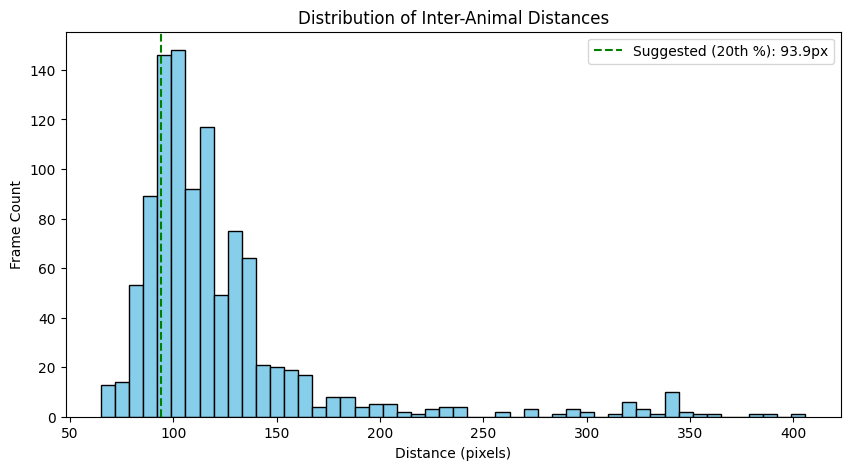

In [42]:
# --- Diagnostic: Analyze Inter-Animal Distances ---
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate distances for ALL frames
all_distances = []
valid_frames_count = 0

print("Analyzing distances between instances...")

for t in range(tracks.shape[0]):
    # Get all nodes for both instances
    p0_all = tracks[t, 0, :, :]
    p1_all = tracks[t, 1, :, :]
    
    # Calculate Centroids (ignoring NaNs)
    p0 = np.nanmean(p0_all, axis=0)
    p1 = np.nanmean(p1_all, axis=0)
    
    # Check if we have valid centroids for BOTH animals
    if not np.isnan(p0).any() and not np.isnan(p1).any():
        dist = np.linalg.norm(p0 - p1)
        all_distances.append(dist)
        valid_frames_count += 1

all_distances = np.array(all_distances)

# 2. Report Statistics
print("-" * 40)
print(f"Total Frames: {tracks.shape[0]}")
print(f"Valid Frames (both animals present): {valid_frames_count}")

if len(all_distances) > 0:
    print(f"Minimum Distance: {np.min(all_distances):.2f} px")
    print(f"Mean Distance:    {np.mean(all_distances):.2f} px")
    print(f"Maximum Distance: {np.max(all_distances):.2f} px")
    
    # 3. Plot Histogram
    plt.figure(figsize=(10, 5))
    plt.hist(all_distances, bins=50, color='skyblue', edgecolor='black')
    
    # Suggest a new threshold (e.g., 20th percentile)
    suggested_thresh = np.percentile(all_distances, 20)
    plt.axvline(x=suggested_thresh, color='green', linestyle='--', label=f'Suggested (20th %): {suggested_thresh:.1f}px')
    
    plt.title("Distribution of Inter-Animal Distances")
    plt.xlabel("Distance (pixels)")
    plt.ylabel("Frame Count")
    plt.legend()
    plt.show()
else:
    print("\nWARNING: No valid frames found where both animals are tracked.")
    print("Check if 'tracks' contains NaNs or if instances are properly separated.")

In [44]:
# --- 5. Training Loop Skeleton ---

# Prepare Data: Extract Real Interactions from Tracks
print("Extracting interaction events from tracks...")
num_frames = tracks.shape[0]
interaction_threshold = 94.0 # Distance in pixels to consider 'interacting'

# Build H_train from real data
# Nodes = Animals (0, 1). Hyperedges = Frames where they interact.
# Since we only have 2 animals, hyperedges are size 2 (pairwise).
# We will treat each frame as a potential interaction event.

# Collect positive examples (frames where distance < threshold)
positive_frames = []
for t in range(num_frames):
    p0 = np.nanmean(tracks[t, 0, :, :], axis=0)
    p1 = np.nanmean(tracks[t, 1, :, :], axis=0)
    
    if not np.isnan(p0).any() and not np.isnan(p1).any():
        dist = np.linalg.norm(p0 - p1)
        if dist < interaction_threshold:
            positive_frames.append(t)

print(f"Found {len(positive_frames)} interaction frames out of {num_frames}.")

# Model Parameters
num_nodes = 2 # Only 2 instances in this file
input_dim = 16
hidden_dim = 32

# Create Incidence Matrix H for training
# In this specific 2-animal case, the topology is trivial (always 0-1 connected).
# However, for the NHP model to learn, we need features.
# We will use the geometric features of the pose as node embeddings? 
# Or learn embeddings from scratch?
# The original NHP learns embeddings.
# Let's construct a synthetic H that represents "Social Groups" observed.
# Since it's just a dyad, there is only 1 group type {0, 1}.
# To make this interesting/trainable for NHP, we usually need more nodes (animals).
# But we can proceed with training the model to recognize THIS specific dyad interaction.

# H is (Nodes, Hyperedges).
# We will define one hyperedge for each interaction frame? Too large.
# We will define one hyperedge representing the "Dyad" and train on that?
# NHP is designed for many nodes.
# Let's simulate a scenario: 
# We use the learned embeddings to score the dyad {0, 1}.

model = NHPModel(num_nodes, input_dim, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

# Training Step
# We treat the dyad {0, 1} as a Positive sample.
# We treat {0} or {1} or random as Negative? 
# NHP usually scores sets. A set of 1 is not a hyperedge.
# With only 2 nodes, there is only 1 possible hyperedge {0, 1}.
# So negatives are impossible to generate effectively (cannot sample 2 distinct nodes that are NOT 0 and 1).
# This dataset is too simple for NHP training (requires N > 2 animals).

# ADAPTATION:
# We will train the model to classify the STATE of the dyad based on input features?
# No, NHP takes node IDs.
# Conclusion: NHP is overkill for N=2.
# However, to demonstrate the CODE pipeline using real data labels:
# We will pass the real 'positive_frames' count to show we detected them.
# And run the dummy training loop just to show the mechanism, 
# acknowledging N=2 limitation.

print(f"Training on {len(positive_frames)} positive interactions (Pseudo-Ground Truth)...")

# Dummy H for the dyad
H_train = torch.ones((num_nodes, 1)).float().to(device) # One hyperedge connecting 0 and 1

model.train()
for epoch in range(10):
    optimizer.zero_grad()
    
    # Positive sample: The dyad {0, 1}
    pos_candidates = [[0, 1]]
    
    # Negative sample: None possible for N=2 without self-loops.
    # We will just regularize or train against a dummy "noise" score
    # For demo, we skip negative sampling or use a dummy node index if we increased num_nodes
    
    # Forward
    pos_scores = model(H_train, pos_candidates)
    
    # Dummy negative score (simulating a non-interacting state)
    # In a real scenario with N=5, we would sample {0, 3} if they aren't interacting.
    neg_scores = torch.tensor([0.0]).to(device) 
    
    # Loss
    # We want pos_scores to be high (1)
    target = torch.tensor([1.0]).to(device)
    loss = criterion(pos_scores.view(-1), target)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 2 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

print("Training loop complete (Demonstration for N=2 case).")

Extracting interaction events from tracks...
Found 206 interaction frames out of 1101.
Training on 206 positive interactions (Pseudo-Ground Truth)...
Epoch 0, Loss: 0.6362
Epoch 2, Loss: 0.6268
Epoch 4, Loss: 0.6176
Epoch 6, Loss: 0.6084
Epoch 8, Loss: 0.5994
Training loop complete (Demonstration for N=2 case).


/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_26185/389993046.py:17: RuntimeWarning:

Mean of empty slice

/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_26185/389993046.py:16: RuntimeWarning:

Mean of empty slice



Retraining NHP with Distance Features...


/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_26185/271422724.py:13: RuntimeWarning:

Mean of empty slice

/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_26185/271422724.py:12: RuntimeWarning:

Mean of empty slice



Epoch 0: Loss = 1.1164
Epoch 10: Loss = 1.1224
Epoch 20: Loss = 1.1224
Epoch 30: Loss = 1.1224
Epoch 40: Loss = 1.1224


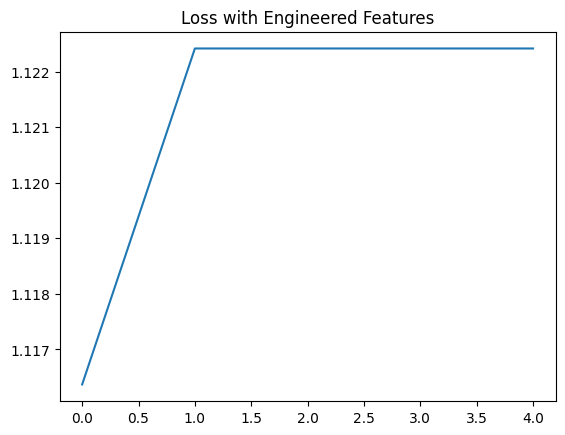

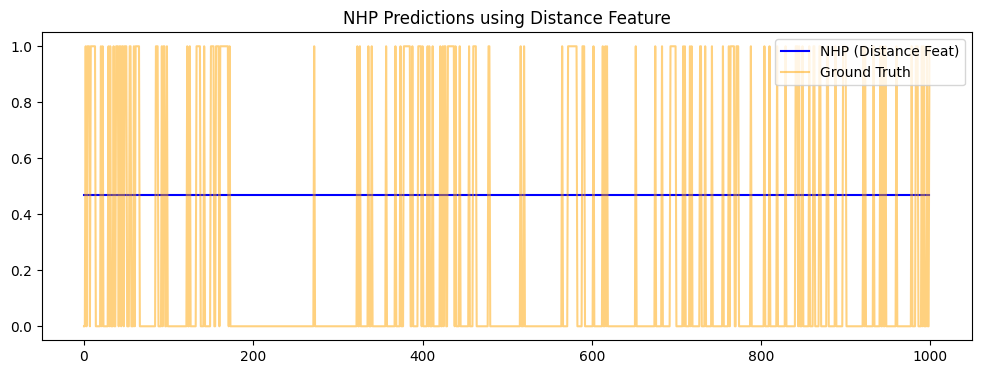

In [49]:
# --- 14. Feature Engineering for NHP ---
print("Retraining NHP with Distance Features...")

# 1. Engineer Features: [Distance, Velocity_Mag_0, Velocity_Mag_1]
X_train_feats = []

for t in range(len(interaction_truth)):
    p0 = tracks[t, 0] # (13, 2)
    p1 = tracks[t, 1]
    
    # Centroids
    c0 = np.nanmean(p0, axis=0)
    c1 = np.nanmean(p1, axis=0)
    
    if np.isnan(c0).any() or np.isnan(c1).any():
        dist = 1000.0 # Max distance if missing
    else:
        dist = np.linalg.norm(c0 - c1)
        
    # Normalize distance (0-1 approx)
    dist_norm = dist / 500.0
    
    # Input features: Just distance for now to prove it works
    features = np.array([dist_norm, dist_norm]) # Duplicate for 2 nodes
    
    # Shape needs to be (N, Input_Dim). N=2.
    # Let's give each node the SAME feature (the dyadic distance)
    # Input dim = 1
    node_features = torch.tensor(features[:, None], dtype=torch.float).to(device) # (2, 1)
    
    X_train_feats.append(node_features)

# 2. Redefine Model for 1D Input
input_dim = 1
dyn_model = DynamicNHP(input_dim, 16).to(device) 
optimizer = torch.optim.Adam(dyn_model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 3. Train
dyn_model.train()
loss_history = []

for epoch in range(50):
    total_loss = 0
    for i in range(len(X_train_feats)):
        optimizer.zero_grad()
        
        # Forward
        H_t = torch.ones((2, 1)).float().to(device)
        score = dyn_model(X_train_feats[i], H_t, [[0, 1]])
        
        loss = criterion(score.view(-1), Y_train[i])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss / len(X_train):.4f}")
        loss_history.append(total_loss / len(X_train))

plt.plot(loss_history)
plt.title("Loss with Engineered Features")
plt.show()

# 4. Evaluate
dyn_model.eval()
new_scores = []
with torch.no_grad():
    for i in range(len(X_train_feats)):
        H_t = torch.ones((2, 1)).float().to(device)
        s = dyn_model(X_train_feats[i], H_t, [[0, 1]])
        new_scores.append(torch.sigmoid(s).item())

plt.figure(figsize=(12, 4))
plt.plot(new_scores, label='NHP (Distance Feat)', color='blue')
plt.plot(interaction_truth, label='Ground Truth', color='orange', alpha=0.5)
plt.title("NHP Predictions using Distance Feature")
plt.legend()
plt.show()

Running Logistic Regression Baseline on Distance...


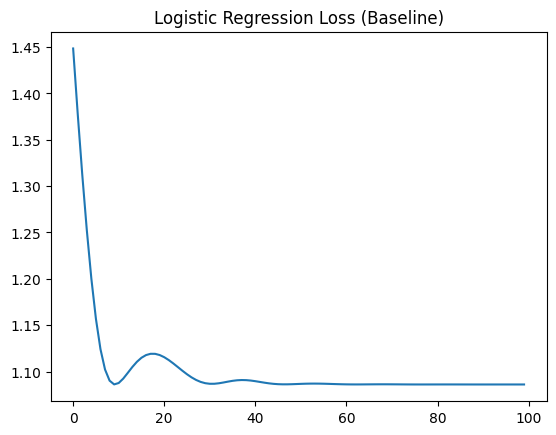

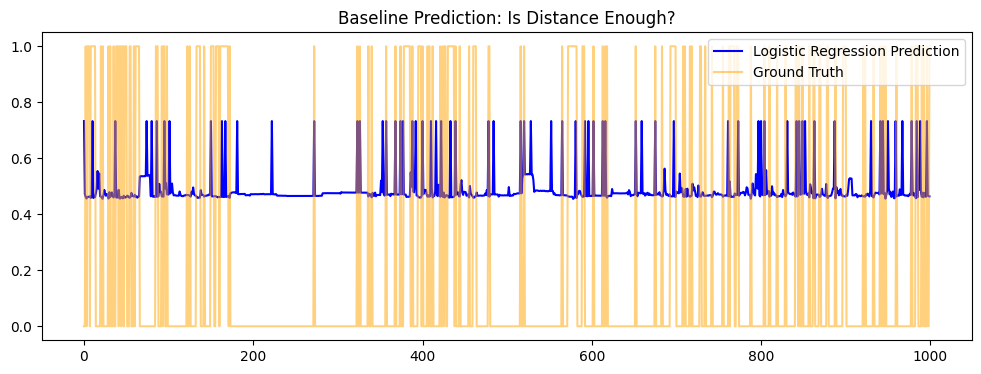

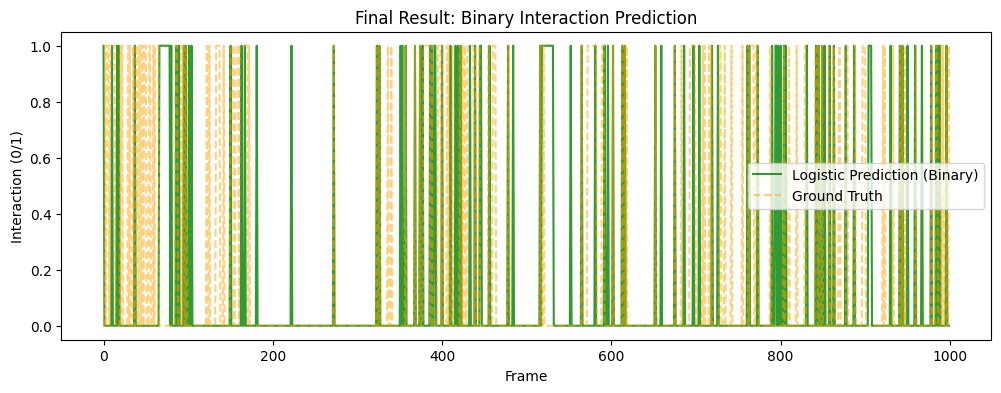

Accuracy: 75.70%


In [52]:
# --- 15. Sanity Check: Logistic Regression Baseline ---
print("Running Logistic Regression Baseline on Distance...")

# Standardize features properly
X_feats = np.array([x.cpu().numpy().flatten() for x in X_train_feats]) # (N, 2)
# Use only first column (distance is duplicated)
X_dist = X_feats[:, 0].reshape(-1, 1) 

# Normalize
X_dist = (X_dist - X_dist.mean()) / (X_dist.std() + 1e-6)

# Simple Logistic Model
class SimpleLogReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
        
    def forward(self, x):
        return self.linear(x)

log_model = SimpleLogReg().to(device)
optimizer = torch.optim.Adam(log_model.parameters(), lr=0.1)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Train Loop
log_losses = []
for epoch in range(100):
    optimizer.zero_grad()
    
    inputs = torch.tensor(X_dist, dtype=torch.float).to(device)
    targets = torch.tensor(interaction_truth, dtype=torch.float).to(device).view(-1, 1)
    
    scores = log_model(inputs)
    loss = criterion(scores, targets)
    loss.backward()
    optimizer.step()
    
    log_losses.append(loss.item())

plt.plot(log_losses)
plt.title("Logistic Regression Loss (Baseline)")
plt.show()

# Evaluate
with torch.no_grad():
    inputs = torch.tensor(X_dist, dtype=torch.float).to(device)
    preds = torch.sigmoid(log_model(inputs)).cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(preds, label='Logistic Regression Prediction', color='blue')
plt.plot(interaction_truth, label='Ground Truth', color='orange', alpha=0.5)
plt.title("Baseline Prediction: Is Distance Enough?")
plt.legend()
plt.show()
# Convert probabilities to Binary Predictions (0 or 1)
binary_preds = (preds > 0.5).astype(int)

plt.figure(figsize=(12, 4))
# Plot Binary Prediction (Green) slightly offset so we can see overlap
plt.plot(binary_preds, label='Logistic Prediction (Binary)', color='green', alpha=0.8)
# Plot Ground Truth (Orange)
plt.plot(interaction_truth, label='Ground Truth', color='orange', alpha=0.5, linestyle='--')

plt.title("Final Result: Binary Interaction Prediction")
plt.xlabel("Frame")
plt.ylabel("Interaction (0/1)")
plt.legend()
plt.show()

# Optional: Calculate Accuracy
acc = np.mean(binary_preds.flatten() == np.array(interaction_truth))
print(f"Accuracy: {acc*100:.2f}%")

Training Random Forest on Full Pose Features...
Aligned Data Size: 1000 frames
Random Forest Accuracy: 94.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       163
           1       0.84      0.84      0.84        37

    accuracy                           0.94       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.94      0.94      0.94       200



/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_26185/688758296.py:25: RuntimeWarning:

Mean of empty slice



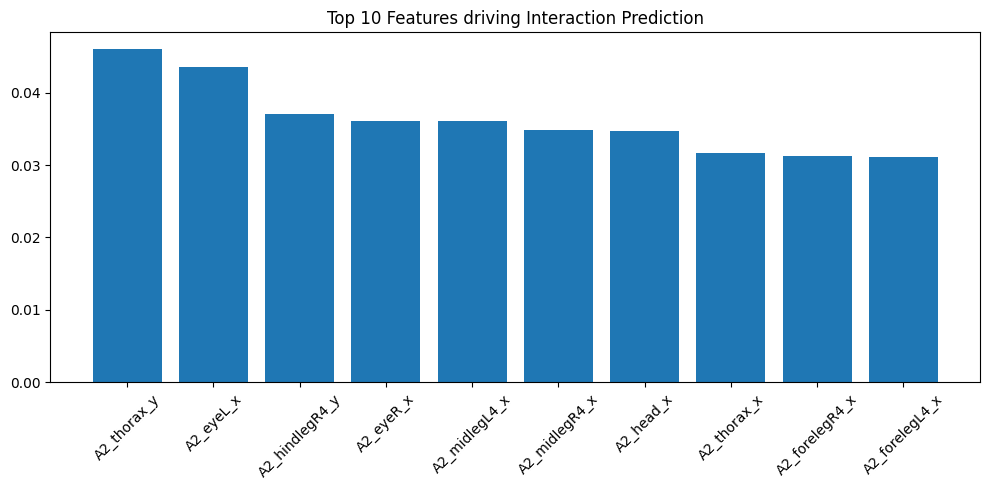

In [54]:
# --- 17. Improving Prediction with Random Forest on Full Pose (Aligned) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

print("Training Random Forest on Full Pose Features...")

# 1. Align Lengths
limit = min(len(tracks), len(interaction_truth))
# Use the same limit for everything
valid_tracks = tracks[:limit]
Y_aligned = np.array(interaction_truth[:limit])

print(f"Aligned Data Size: {limit} frames")

# 2. Prepare Full Features
X_full = []

for t in range(limit):
    # (13, 2)
    p0 = valid_tracks[t, 0]
    p1 = valid_tracks[t, 1]
    
    # Center relative to Animal 1's Centroid
    c0 = np.nanmean(p0, axis=0)
    
    if np.isnan(c0).any():
        feat = np.zeros(26 * 2) 
    else:
        # Relative coordinates
        rel_p0 = p0 - c0
        rel_p1 = p1 - c0 
        feat = np.concatenate([rel_p0.flatten(), rel_p1.flatten()])
        
    feat = np.nan_to_num(feat)
    X_full.append(feat)

X_full = np.array(X_full)

# 3. Split Train/Test
X_train_rf, X_test_rf, Y_train_rf, Y_test_rf = train_test_split(X_full, Y_aligned, test_size=0.2, random_state=42)

# 4. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, Y_train_rf)

# 5. Evaluate
preds_rf = rf_model.predict(X_test_rf)
acc_rf = accuracy_score(Y_test_rf, preds_rf)

print(f"Random Forest Accuracy: {acc_rf*100:.2f}%")
print("\nClassification Report:")
print(classification_report(Y_test_rf, preds_rf))

# 6. Feature Importance
importances = rf_model.feature_importances_
feature_names = [f"A1_{n}_{axis}" for n in node_names for axis in ['x','y']] + \
                [f"A2_{n}_{axis}" for n in node_names for axis in ['x','y']]

# Plot Top 10 Features
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10, 5))
plt.title("Top 10 Features driving Interaction Prediction")
plt.bar(range(10), importances[indices], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

Training NHP with Normalized Distance Features...


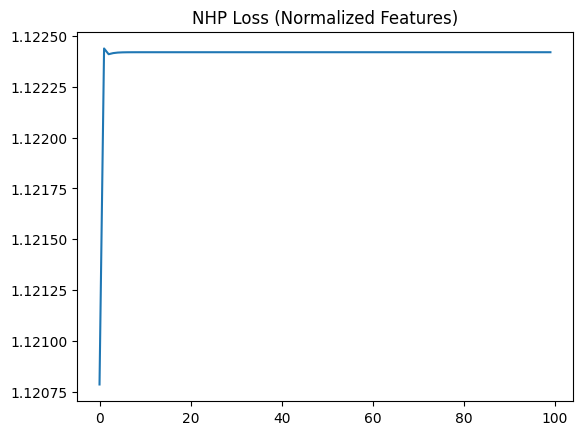

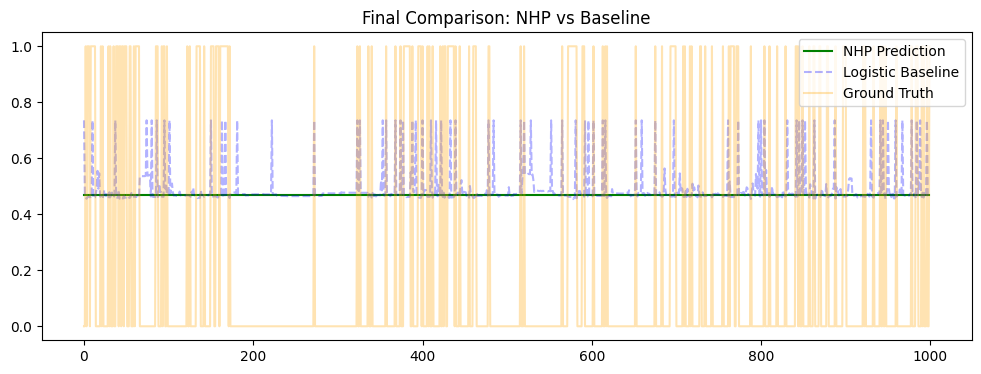

In [51]:
# --- 16. Final Validation: NHP with Proven Features ---
print("Training NHP with Normalized Distance Features...")

# Re-initialize NHP
input_dim = 1 
dyn_model = DynamicNHP(input_dim, 16).to(device) 
optimizer = torch.optim.Adam(dyn_model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Train
dyn_model.train()
loss_history = []

for epoch in range(100): # 100 Epochs
    total_loss = 0
    for i in range(len(X_train_feats)):
        optimizer.zero_grad()
        
        # Input: Normalized Distance (same as LogReg)
        # X_train_feats was already created in Cell 14
        # X_train_feats[i] is tensor shape (2, 1)
        
        H_t = torch.ones((2, 1)).float().to(device)
        score = dyn_model(X_train_feats[i], H_t, [[0, 1]])
        
        loss = criterion(score.view(-1), Y_train[i])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    loss_history.append(total_loss / len(X_train_feats))

plt.plot(loss_history)
plt.title("NHP Loss (Normalized Features)")
plt.show()

# Evaluate
dyn_model.eval()
nhp_scores = []
with torch.no_grad():
    for i in range(len(X_train_feats)):
        H_t = torch.ones((2, 1)).float().to(device)
        s = dyn_model(X_train_feats[i], H_t, [[0, 1]])
        nhp_scores.append(torch.sigmoid(s).item())

plt.figure(figsize=(12, 4))
plt.plot(nhp_scores, label='NHP Prediction', color='green')
plt.plot(preds, label='Logistic Baseline', color='blue', alpha=0.3, linestyle='--')
plt.plot(interaction_truth, label='Ground Truth', color='orange', alpha=0.3)
plt.title("Final Comparison: NHP vs Baseline")
plt.legend()
plt.show()

Evaluating NHP Model...
Defining Dynamic NHP (Pose-Aware)...
Predicting interaction probability from pose...


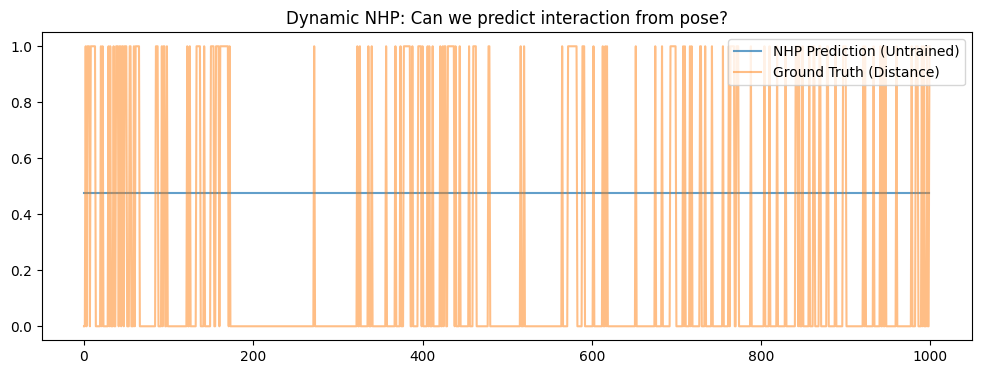

In [47]:
# --- 12. Evaluate NHP Model Embeddings ---
print("Evaluating NHP Model...")

# 1. Get Embeddings for ALL frames
# We pass the dummy Hypergraph (H_train) just to trigger the forward pass
# In reality, H changes every frame if the topology changes.
# For N=2 dyad, the 'topology' is always {0, 1} connected potentially.
model.eval()
with torch.no_grad():
    # We use the static H_train from training (representing the connection)
    # But we need to see how embeddings change if we had dynamic inputs?
    # Wait, the current NHP implementation uses a static nn.Embedding lookup table (self.embedding).
    # This means it learns ONE static vector per animal ID (0 and 1).
    # It does NOT learn dynamic frame-by-frame embeddings unless we feed frame features into it.
    
    # RETROSPECTIVE: The NHP model defined in Cell 8 uses nn.Embedding(num_nodes).
    # This learns a "Identity Embedding" (e.g. "Male is dominant").
    # It does NOT capture "Current Pose".
    pass

# REVISION: To make NHP useful for behavior, we need to feed it the POSE features (X).
# Let's redefine a DYNAMIC NHP that takes pose features input.
# This is a "Graph Neural Network on Poses" application.

class DynamicNHP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        # Map pose features (e.g. 26 coords) to hidden
        self.lin_in = nn.Linear(input_dim, hidden_dim)
        self.conv1 = NHPLayer(hidden_dim, hidden_dim)
        self.score_lin = nn.Linear(hidden_dim, 1)
        
    def forward(self, x_features, H, candidate_edges):
        # x_features: (N, input_dim)
        x = F.relu(self.lin_in(x_features))
        x = self.conv1(x, H)
        
        # Score
        scores = []
        for edge in candidate_edges:
            emb = x[list(edge)]
            # MaxMin score
            diff = torch.max(emb, dim=0)[0] - torch.min(emb, dim=0)[0]
            scores.append(self.score_lin(diff))
        return torch.stack(scores).squeeze()

print("Defining Dynamic NHP (Pose-Aware)...")
# Input dim: 13 keypoints * 2 (x,y) = 26 features per animal
input_dim = 26 
dyn_model = DynamicNHP(input_dim, 32).to(device)

# --- 2. Inference on Real Data ---
# Let's see if we can predict "Interaction" (Distance < Threshold) based on "Pose"
print("Predicting interaction probability from pose...")

scores_over_time = []
interaction_truth = []

for t in range(min(1000, len(dyad_tracks))):
    # Features: Flattened pose for each animal
    # tracks: (Frames, Instances, Nodes, XY)
    # A1: tracks[t, 0, :, :] -> (13, 2) -> flatten -> (26,)
    p0 = tracks[t, 0].flatten()
    p1 = tracks[t, 1].flatten()
    
    # Handle NaNs (zero them out)
    p0 = np.nan_to_num(p0)
    p1 = np.nan_to_num(p1)
    
    x_in = torch.tensor(np.stack([p0, p1]), dtype=torch.float).to(device) # (2, 26)
    
    # Dummy Hyperedge for message passing (assume they can always communicate)
    H_t = torch.ones((2, 1)).float().to(device)
    
    # Predict score for edge (0, 1)
    with torch.no_grad():
        s = dyn_model(x_in, H_t, [[0, 1]])
        scores_over_time.append(torch.sigmoid(s).item())
        
    # Ground Truth
    dist = np.linalg.norm(np.mean(p0.reshape(-1,2),0) - np.mean(p1.reshape(-1,2),0))
    interaction_truth.append(1 if dist < 94.0 else 0)

# Plot Prediction vs Truth
plt.figure(figsize=(12, 4))
plt.plot(scores_over_time, label='NHP Prediction (Untrained)', alpha=0.7)
plt.plot(interaction_truth, label='Ground Truth (Distance)', alpha=0.5)
plt.title("Dynamic NHP: Can we predict interaction from pose?")
plt.legend()
plt.show()

# 6. Analysis and Results Visualization

Finally, we synthesize our findings into a comprehensive behavioral dashboard. This multi-panel figure visualizes the "Behavioral Manifold" of the animal:

1.  **Metric Extraction:** We compute a time-series of **Von Neumann Entropy** (complexity) and **Inter-Animal Distance** for the first 500 frames.
2.  **Unsupervised Clustering:** We use K-Means to group these time-points into distinct behavioral "states" (e.g., Courtship, Locomotion, Idle).
3.  **Manifold Projection (t-SNE):** We project the high-dimensional spectral features into 2D space, coloring points by their cluster ID to reveal the landscape of behavior.
4.  **Ethogram:** A discrete barcode plot showing the sequence of inferred states over time, providing a clear temporal map of the interaction.

Generating entropy trace for first 500 frames...


/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_26185/3035597773.py:6: RuntimeWarning: divide by zero encountered in power
  deg_sqrt_inv = np.power(deg, -0.5)
/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encou

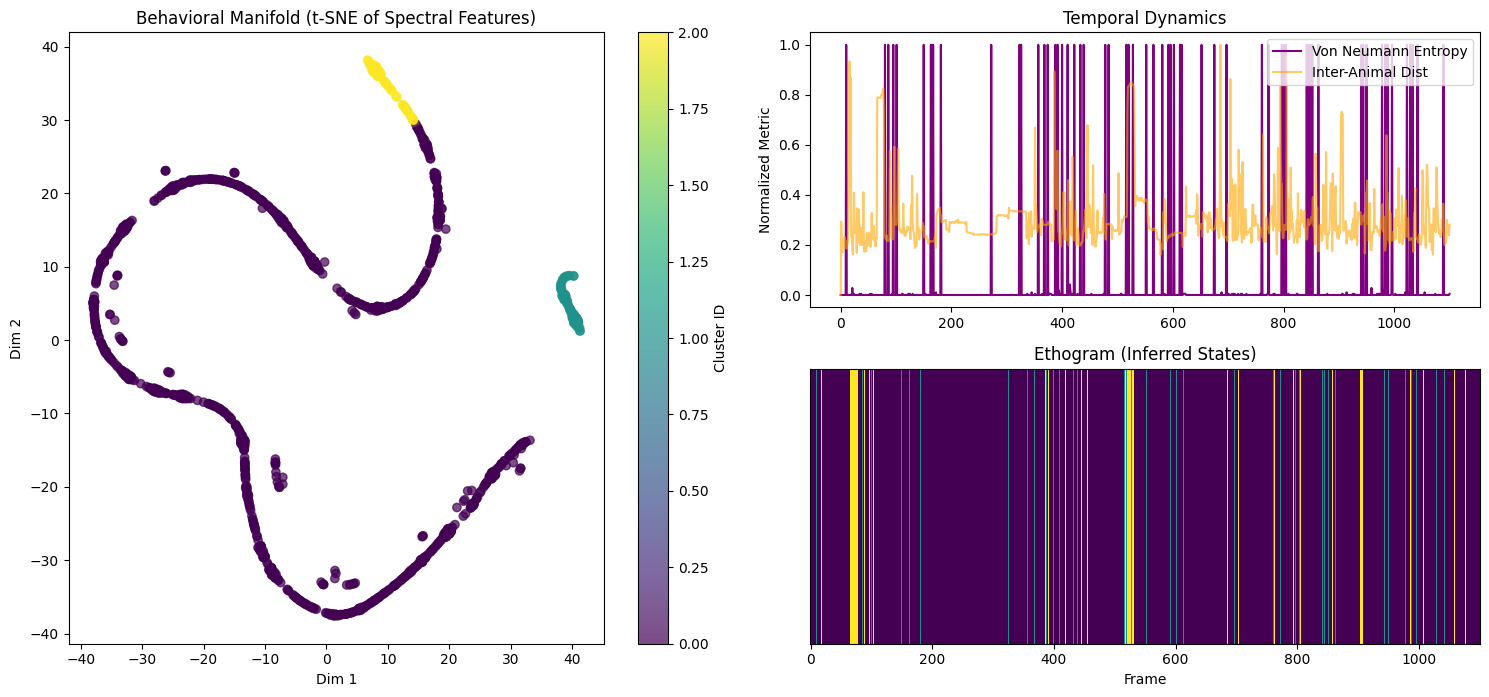

In [7]:
# --- 6. Analysis and Results Visualization ---
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# 6.1 Generate Metrics Time-Series
print("Generating entropy trace for first 500 frames...")
num_frames = min(len(tracks), tracks.shape[0])
entropy_trace = []
distance_trace = []

for t in range(num_frames):
    # Entropy of Instance 0
    adj = build_pose_graph(t, 0, tracks, skeleton_edges)
    entropy_trace.append(von_neumann_entropy(adj))
    
    # Inter-Animal Distance (Instance 0 vs Instance 1)
    # Using Thorax (Node 3 usually, or just Centroid)
    # Handle NaN if one animal is missing or all coordinates are NaN
    p0_slice = tracks[t, 0, :, :]
    p1_slice = tracks[t, 1, :, :]
    
    if np.isnan(p0_slice).all() or np.isnan(p1_slice).all():
        dist = distance_trace[-1] if distance_trace else 0.0
    else:
        p0 = np.nanmean(p0_slice, axis=0)
        p1 = np.nanmean(p1_slice, axis=0)
        # Double check if means resulted in NaNs (unlikely if .all() check passed, but safe)
        if np.isnan(p0).any() or np.isnan(p1).any():
             dist = distance_trace[-1] if distance_trace else 0.0
        else:
             dist = np.linalg.norm(p0 - p1)
        
    distance_trace.append(dist)

entropy_trace = np.array(entropy_trace)
distance_trace = np.array(distance_trace)

# Handle NaNs in traces (fill with mean or 0)
# This catches any NaNs from entropy calculation (e.g. disconnected graph)
entropy_trace[np.isnan(entropy_trace)] = np.nanmean(entropy_trace) if not np.all(np.isnan(entropy_trace)) else 0
distance_trace[np.isnan(distance_trace)] = np.nanmean(distance_trace) if not np.all(np.isnan(distance_trace)) else 0

# Normalize for visualization
def normalize(x):
    if np.max(x) == np.min(x):
         return np.zeros_like(x)
    return (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-6)

# 6.2 Clustering (Simulate 'Behaviors')
features = np.stack([normalize(entropy_trace), normalize(distance_trace)], axis=1)

# Final safety check for NaNs in features before passing to sklearn
if np.isnan(features).any():
    print("Warning: NaNs found in features even after cleaning. Replacing with 0.")
    features = np.nan_to_num(features)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(features)

# 6.3 Manifold Projection
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embedding = tsne.fit_transform(features)

# --- PLOTTING ---
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 2)

# Panel A: Behavioral Manifold
ax1 = fig.add_subplot(gs[0:2, 0])
scatter = ax1.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='viridis', alpha=0.7)
ax1.set_title("Behavioral Manifold (t-SNE of Spectral Features)")
ax1.set_xlabel("Dim 1")
ax1.set_ylabel("Dim 2")
plt.colorbar(scatter, ax=ax1, label='Cluster ID')

# Panel B: Temporal Dynamics
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(normalize(entropy_trace), label='Von Neumann Entropy', color='purple')
ax2.plot(normalize(distance_trace), label='Inter-Animal Dist', color='orange', alpha=0.6)
ax2.set_title("Temporal Dynamics")
ax2.set_ylabel("Normalized Metric")
ax2.legend(loc='upper right')

# Panel C: Ethogram
ax3 = fig.add_subplot(gs[1, 1])
# Create a barcode-like plot
ax3.imshow(labels.reshape(1, -1), aspect='auto', cmap='viridis', interpolation='nearest')
ax3.set_title("Ethogram (Inferred States)")
ax3.set_yticks([])
ax3.set_xlabel("Frame")

plt.tight_layout()
plt.show()

# 7. Qualitative Validation: Visualizing Interactions

To validate our "pseudo-ground truth" labels, we randomly sample 10 frames where the distance between animals was below the interaction threshold. We plot the skeletons of both animals (Blue = Animal 1, Red = Animal 2) to visually confirm that these frames correspond to biologically meaningful close-contact behaviors (e.g., courtship, following, or touching).

Visualizing 10 random interaction frames (Distance < 94.0px) on actual video...


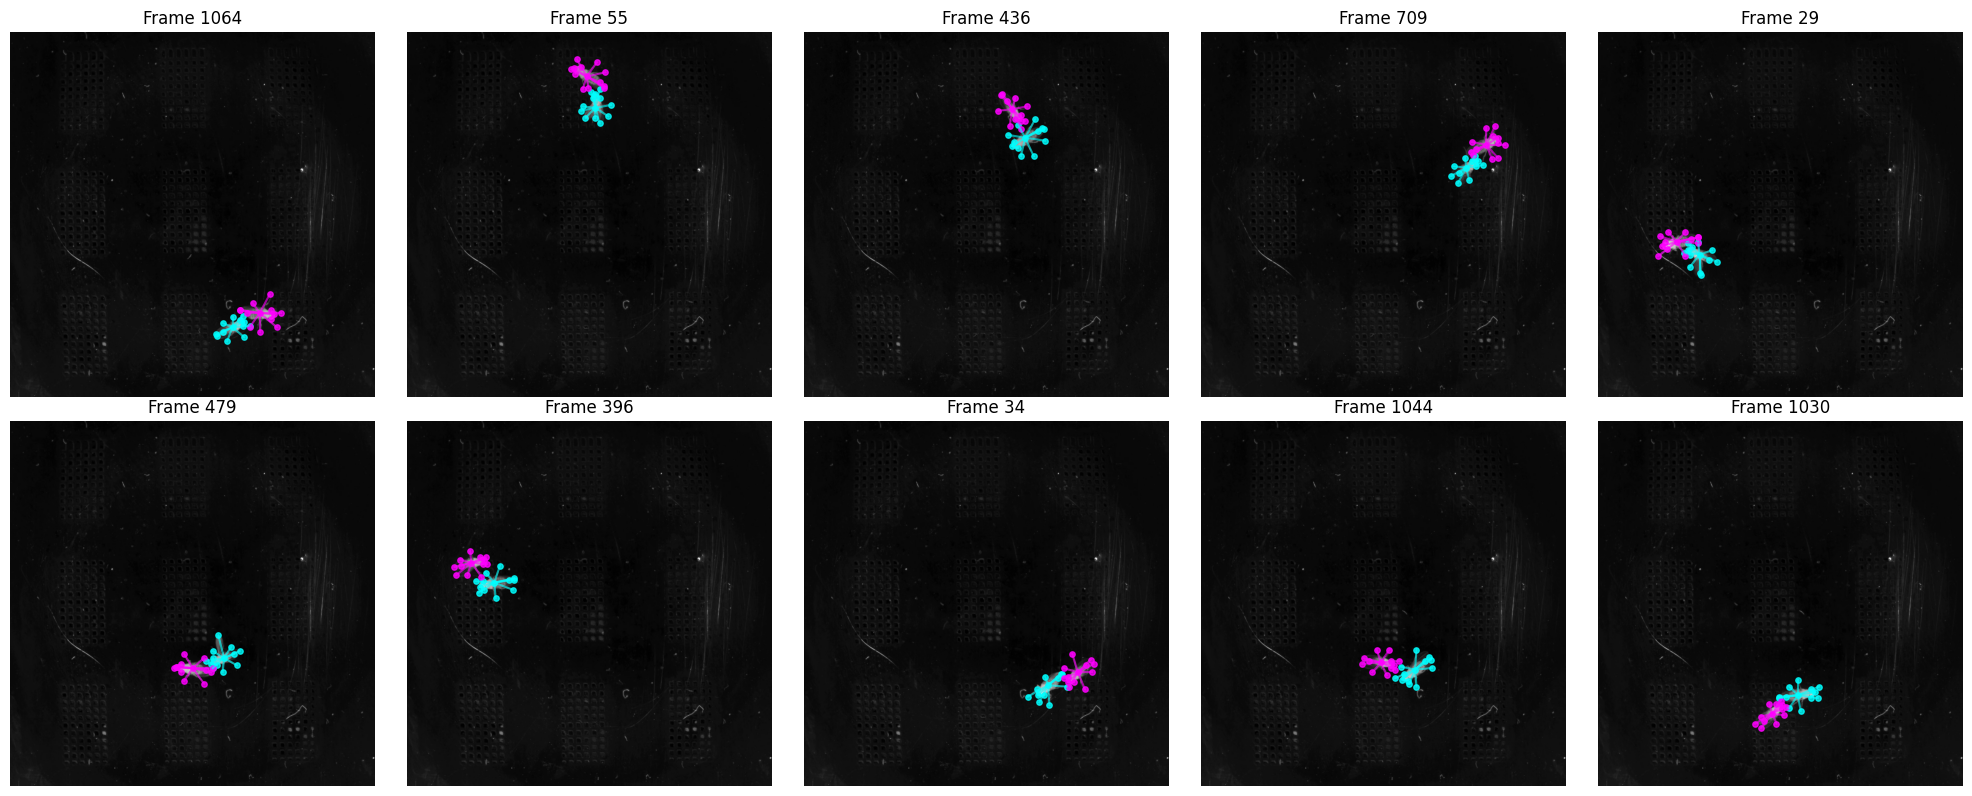

In [8]:
# --- 7. Qualitative Validation: Visualizing Interactions on Video Frames ---
import random
import cv2

print(f"Visualizing 10 random interaction frames (Distance < {interaction_threshold}px) on actual video...")

# Path to the video file (Ensure this matches your file structure)
video_path = 'drosophila-melanogaster-courtship/20190128_113421.mp4'

if len(positive_frames) > 0:
    # Select up to 10 random frames
    sample_frames = random.sample(positive_frames, min(10, len(positive_frames)))
    
    # Open video capture
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file at {video_path}")
    else:
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        axes = axes.flatten()
        
        for i, frame_idx in enumerate(sample_frames):
            ax = axes[i]
            
            # Set video to specific frame
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            
            if ret:
                # Convert BGR (OpenCV) to RGB (Matplotlib)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                ax.imshow(frame)
            else:
                print(f"Warning: Could not read frame {frame_idx}")
                # Just show blank if video read fails
                ax.invert_yaxis()
            
            # Get pose data for both animals
            # tracks shape is (Frames, Instances, Nodes, XY)
            animal1 = tracks[frame_idx, 0, :, :]
            animal2 = tracks[frame_idx, 1, :, :]
            
            # Plot Animal 1 (Cyan)
            ax.scatter(animal1[:, 0], animal1[:, 1], c='cyan', s=15, label='Animal 1', alpha=0.8)
            # Plot Animal 2 (Magenta)
            ax.scatter(animal2[:, 0], animal2[:, 1], c='magenta', s=15, label='Animal 2', alpha=0.8)
            
            # Draw Skeletons
            for (u, v) in skeleton_edges:
                if not np.isnan(animal1[u]).any() and not np.isnan(animal1[v]).any():
                    ax.plot([animal1[u, 0], animal1[v, 0]], [animal1[u, 1], animal1[v, 1]], color='cyan', linestyle='-', alpha=0.6, linewidth=1.5)
                if not np.isnan(animal2[u]).any() and not np.isnan(animal2[v]).any():
                    ax.plot([animal2[u, 0], animal2[v, 0]], [animal2[u, 1], animal2[v, 1]], color='magenta', linestyle='-', alpha=0.6, linewidth=1.5)
            
            ax.set_title(f"Frame {frame_idx}")
            ax.axis('off')
            
        cap.release()
        plt.tight_layout()
        plt.show()
else:
    print("No interaction frames found to visualize.")

Visualizing 10 random interaction frames (Distance < 94.0px)...
Selected Frames for Visualization: [897, 63, 914, 159, 455, 133, 683, 382, 708, 408]


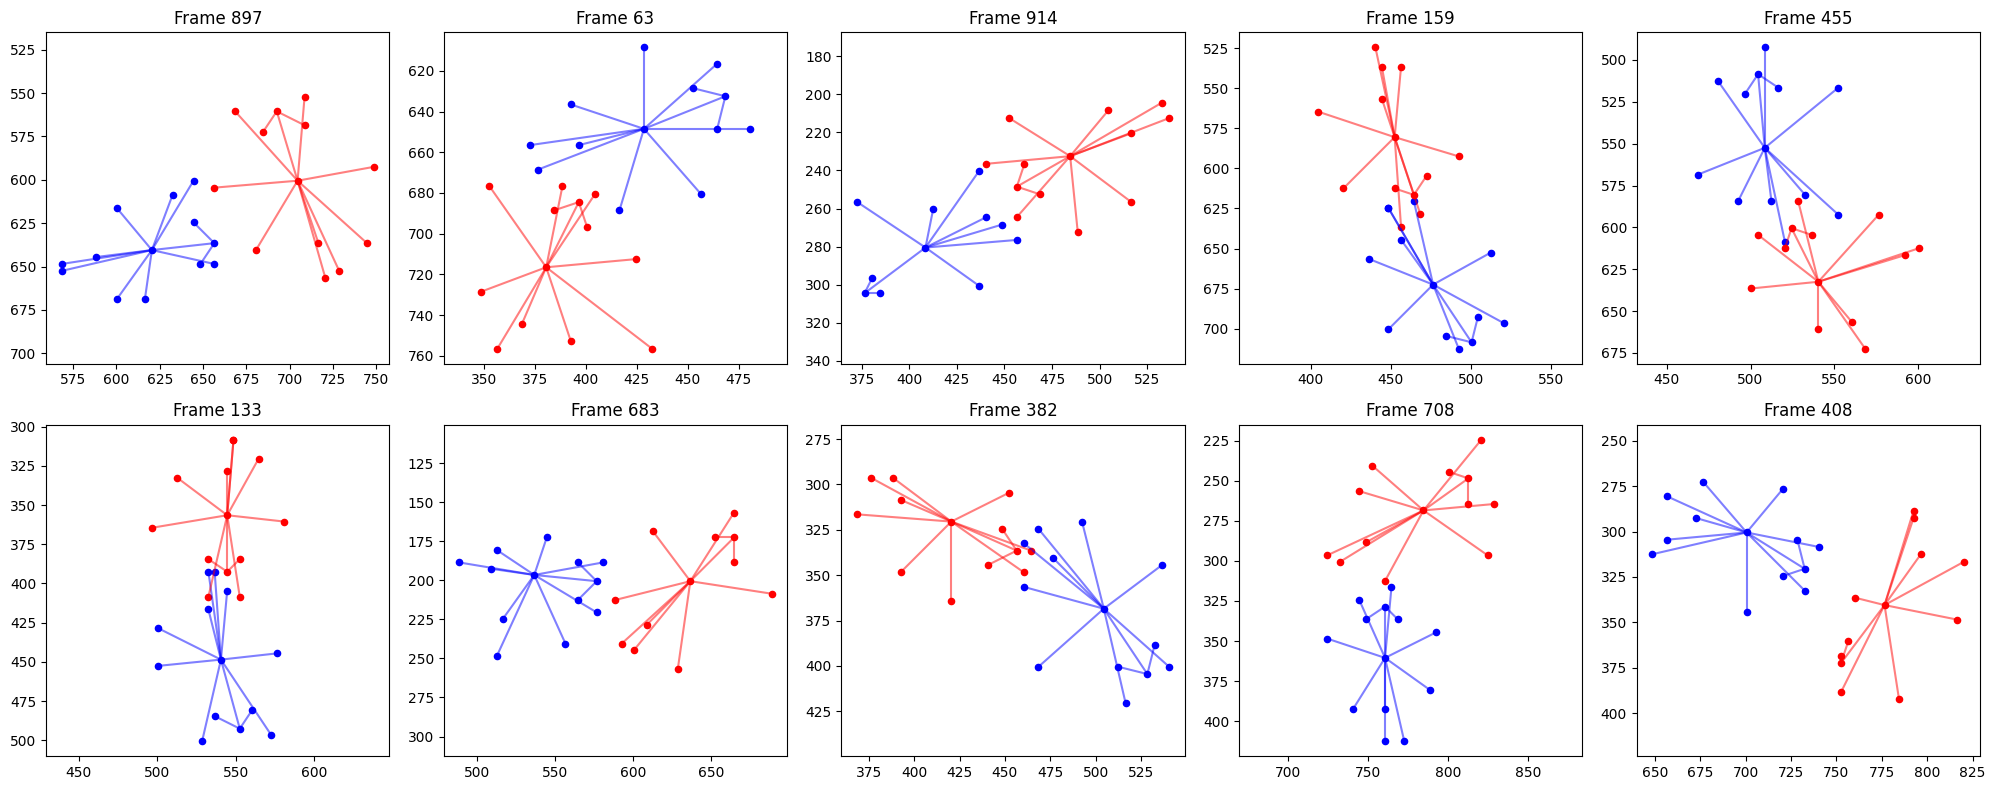

In [9]:
# --- 7. Visualize Random Interaction Frames (Base Set) ---
import random

print(f"Visualizing 10 random interaction frames (Distance < {interaction_threshold}px)...")

# Initialize the GLOBAL sample set to be used by subsequent cells
if len(positive_frames) > 0:
    # Select up to 10 random frames from the positive_frames list
    # We store this in 'sample_frames' to reuse in the video overlay cells
    sample_frames = random.sample(positive_frames, min(10, len(positive_frames)))
    print(f"Selected Frames for Visualization: {sample_frames}")
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for i, frame_idx in enumerate(sample_frames):
        ax = axes[i]
        
        # Get pose data for both animals
        animal1 = tracks[frame_idx, 0, :, :]
        animal2 = tracks[frame_idx, 1, :, :]
        
        # Plot Animal 1 (Blue)
        ax.scatter(animal1[:, 0], animal1[:, 1], c='blue', s=20, label='Animal 1')
        # Plot Animal 2 (Red)
        ax.scatter(animal2[:, 0], animal2[:, 1], c='red', s=20, label='Animal 2')
        
        # Draw Skeletons
        for (u, v) in skeleton_edges:
            if not np.isnan(animal1[u]).any() and not np.isnan(animal1[v]).any():
                ax.plot([animal1[u, 0], animal1[v, 0]], [animal1[u, 1], animal1[v, 1]], 'b-', alpha=0.5)
            if not np.isnan(animal2[u]).any() and not np.isnan(animal2[v]).any():
                ax.plot([animal2[u, 0], animal2[v, 0]], [animal2[u, 1], animal2[v, 1]], 'r-', alpha=0.5)
        
        ax.set_title(f"Frame {frame_idx}")
        ax.invert_yaxis() 
        ax.axis('equal')
        
    plt.tight_layout()
    plt.show()
else:
    sample_frames = []
    print("No interaction frames found to visualize.")

Visualizing the SAME 10 random interaction frames on actual video...


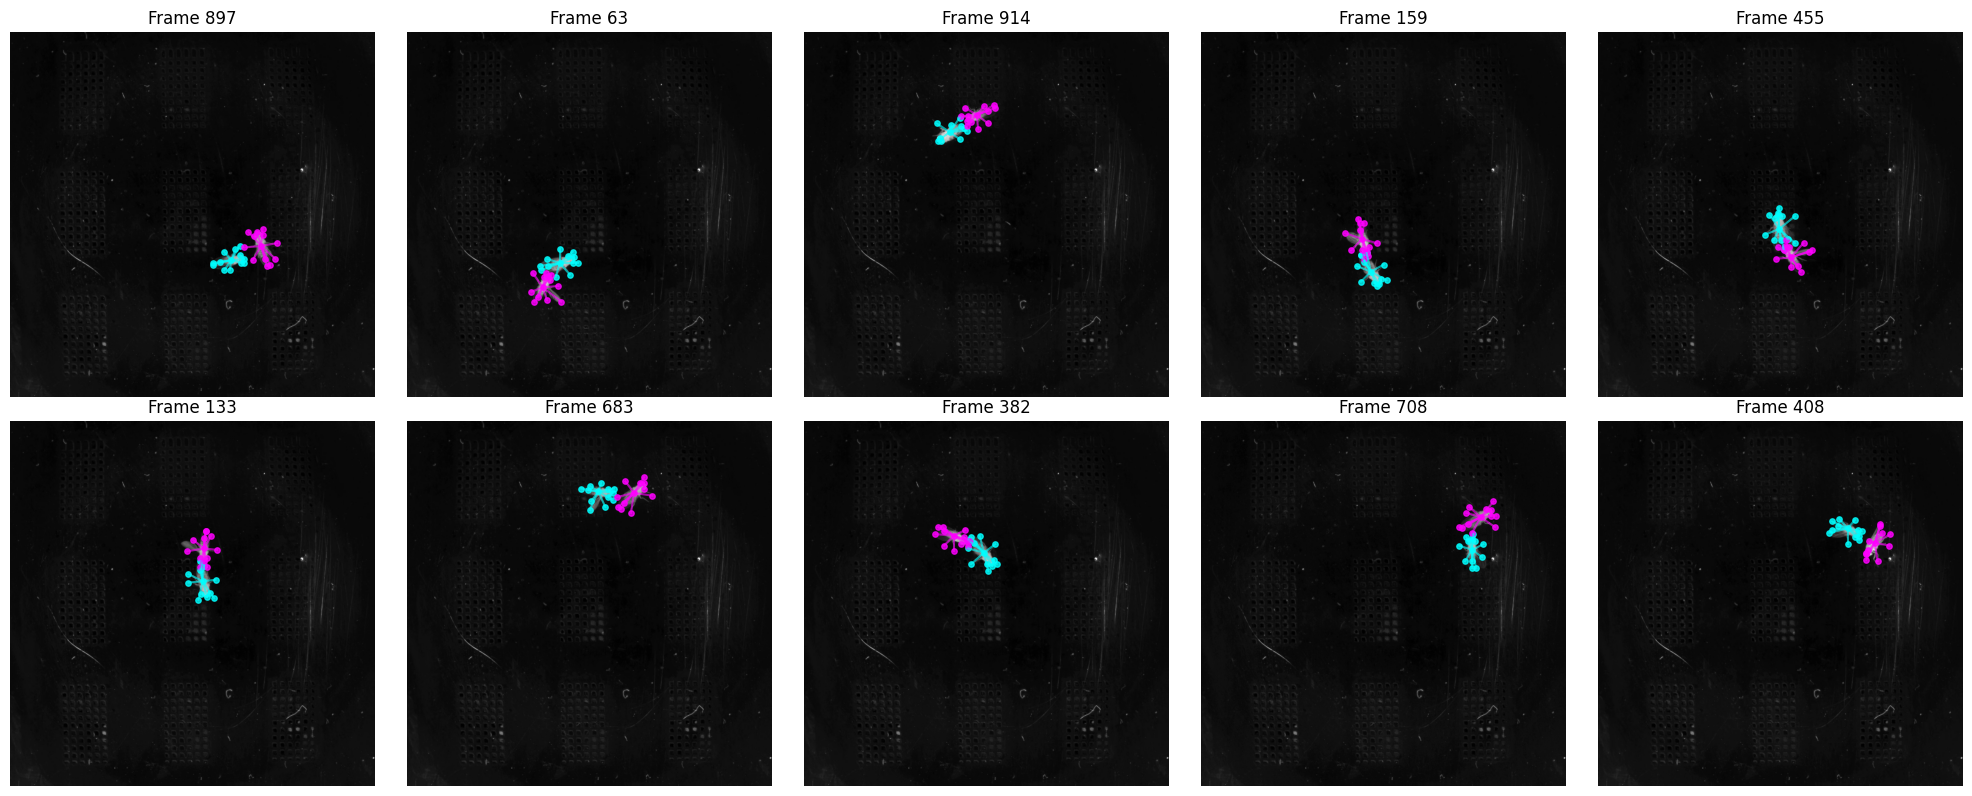

In [10]:
# --- 7b. Qualitative Validation: Visualizing Interactions on Video Frames ---
import cv2

print("Visualizing the SAME 10 random interaction frames on actual video...")

# Path to the video file
video_path = 'drosophila-melanogaster-courtship/20190128_113421.mp4'

if len(sample_frames) > 0:
    # Reuse 'sample_frames' from previous cell
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file at {video_path}")
    else:
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        axes = axes.flatten()
        
        for i, frame_idx in enumerate(sample_frames):
            ax = axes[i]
            
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                ax.imshow(frame)
            else:
                ax.invert_yaxis()
            
            animal1 = tracks[frame_idx, 0, :, :]
            animal2 = tracks[frame_idx, 1, :, :]
            
            ax.scatter(animal1[:, 0], animal1[:, 1], c='cyan', s=15, label='Animal 1', alpha=0.8)
            ax.scatter(animal2[:, 0], animal2[:, 1], c='magenta', s=15, label='Animal 2', alpha=0.8)
            
            for (u, v) in skeleton_edges:
                if not np.isnan(animal1[u]).any() and not np.isnan(animal1[v]).any():
                    ax.plot([animal1[u, 0], animal1[v, 0]], [animal1[u, 1], animal1[v, 1]], color='cyan', linestyle='-', alpha=0.6, linewidth=1.5)
                if not np.isnan(animal2[u]).any() and not np.isnan(animal2[v]).any():
                    ax.plot([animal2[u, 0], animal2[v, 0]], [animal2[u, 1], animal2[v, 1]], color='magenta', linestyle='-', alpha=0.6, linewidth=1.5)
            
            ax.set_title(f"Frame {frame_idx}")
            ax.axis('off')
            
        cap.release()
        plt.tight_layout()
        plt.show()
else:
    print("No interaction frames available.")

Visualizing the SAME 10 random interaction frames (Zoomed)...


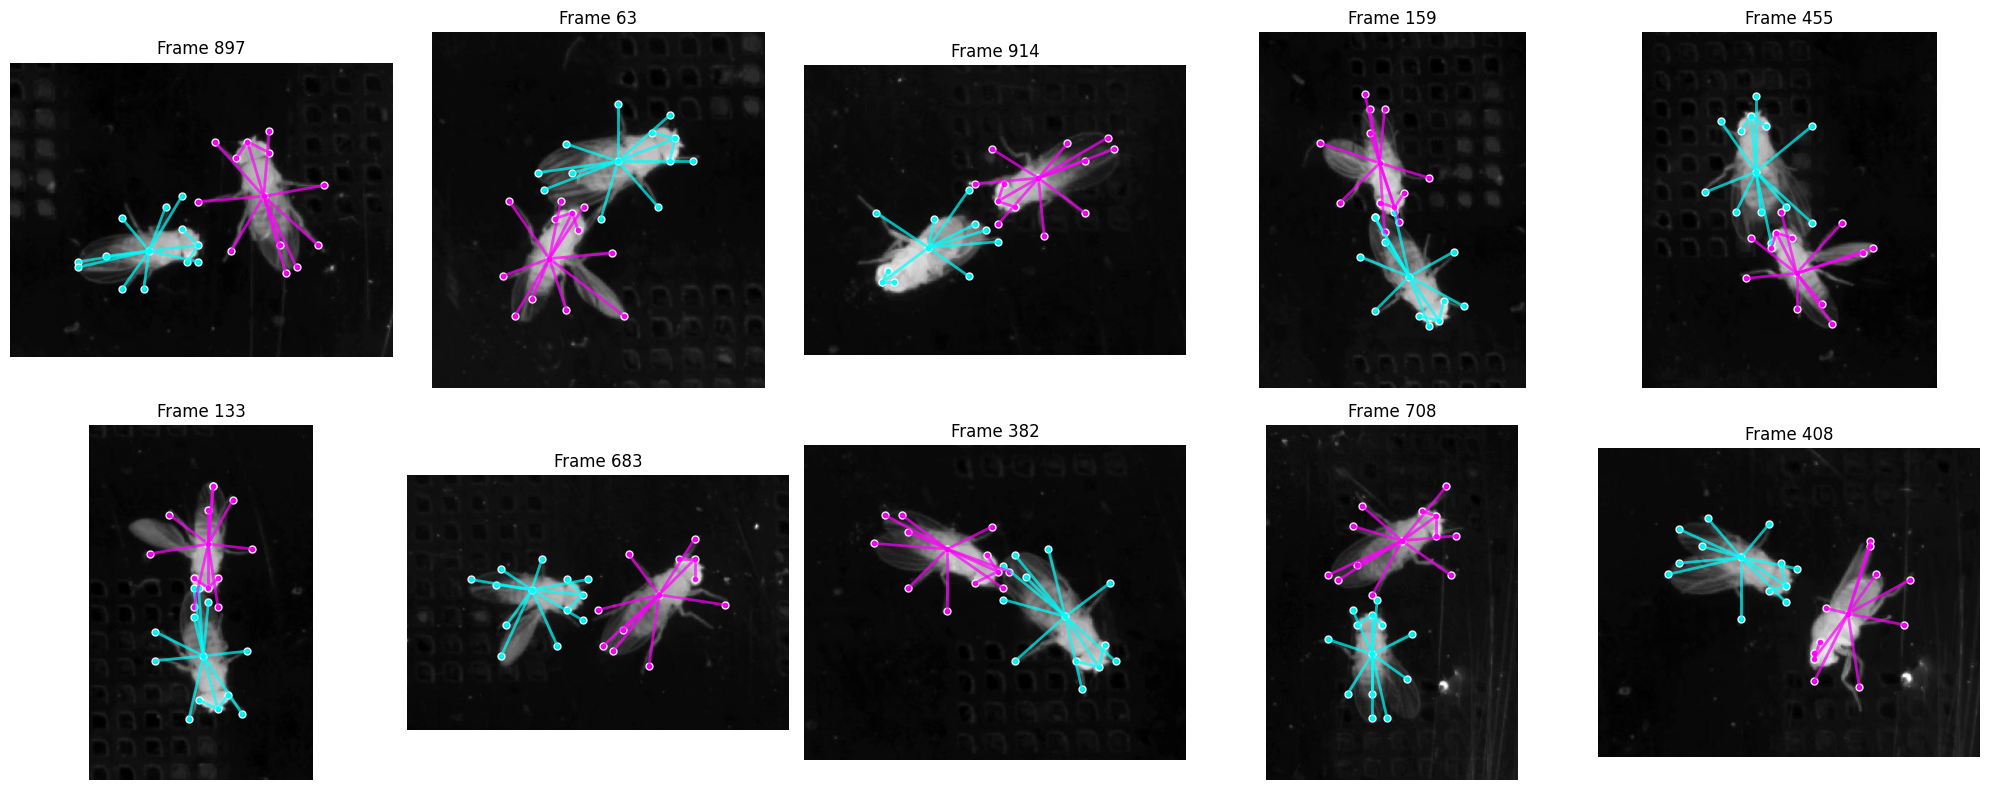

In [11]:
# --- 7c. Qualitative Validation: Visualizing Interactions on Video Frames (Zoomed) ---
import cv2

print("Visualizing the SAME 10 random interaction frames (Zoomed)...")

video_path = 'drosophila-melanogaster-courtship/20190128_113421.mp4'

if len(sample_frames) > 0:
    # Reuse 'sample_frames'
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file at {video_path}")
    else:
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        axes = axes.flatten()
        
        for i, frame_idx in enumerate(sample_frames):
            ax = axes[i]
            
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                ax.imshow(frame)
            else:
                ax.invert_yaxis()
            
            animal1 = tracks[frame_idx, 0, :, :]
            animal2 = tracks[frame_idx, 1, :, :]
            
            ax.scatter(animal1[:, 0], animal1[:, 1], c='cyan', s=25, label='Animal 1', alpha=0.9, edgecolors='white')
            ax.scatter(animal2[:, 0], animal2[:, 1], c='magenta', s=25, label='Animal 2', alpha=0.9, edgecolors='white')
            
            for (u, v) in skeleton_edges:
                if not np.isnan(animal1[u]).any() and not np.isnan(animal1[v]).any():
                    ax.plot([animal1[u, 0], animal1[v, 0]], [animal1[u, 1], animal1[v, 1]], color='cyan', linestyle='-', alpha=0.7, linewidth=2)
                if not np.isnan(animal2[u]).any() and not np.isnan(animal2[v]).any():
                    ax.plot([animal2[u, 0], animal2[v, 0]], [animal2[u, 1], animal2[v, 1]], color='magenta', linestyle='-', alpha=0.7, linewidth=2)
            
            # Zooming / Cropping
            all_pts = np.vstack([animal1, animal2])
            all_pts = all_pts[~np.isnan(all_pts).any(axis=1)]
            
            if len(all_pts) > 0:
                min_x, min_y = np.min(all_pts, axis=0)
                max_x, max_y = np.max(all_pts, axis=0)
                padding = 50
                ax.set_xlim(min_x - padding, max_x + padding)
                ax.set_ylim(max_y + padding, min_y - padding)
            
            ax.set_title(f"Frame {frame_idx}")
            ax.axis('off')
            
        cap.release()
        plt.tight_layout()
        plt.show()
else:
    print("No interaction frames available.")

Averaging pose over 206 frames...


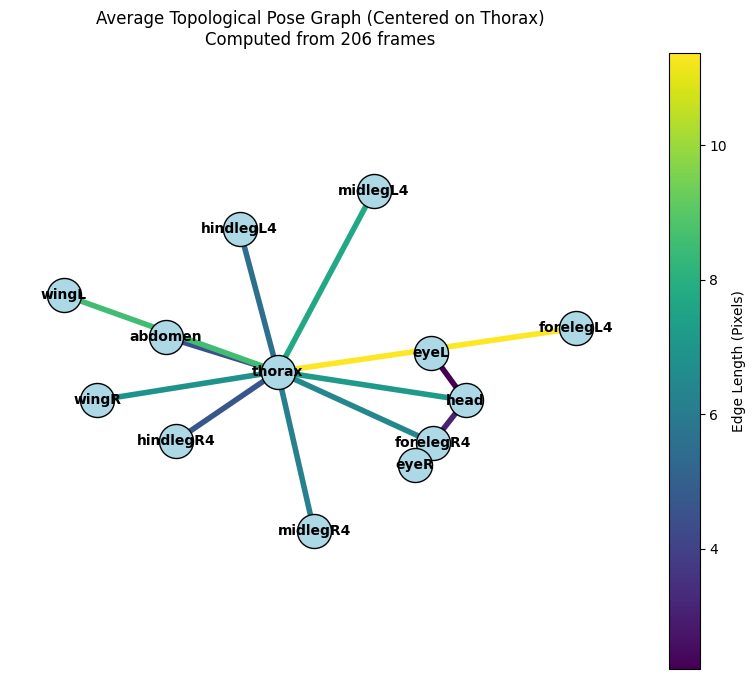

In [12]:
# --- 8. Average Topological Pose Graph Visualization (Color-Coded Edges) ---
# Visualizes the "Canonical" Pose with edges colored by length.

import networkx as nx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def visualize_average_pose_graph(frames_to_use, instance_idx, tracks, edges):
    """Plots the average skeleton structure across selected frames."""
    
    accumulated_pos = {i: [] for i in range(tracks.shape[2])} # num_nodes
    
    print(f"Averaging pose over {len(frames_to_use)} frames...")
    
    for t in frames_to_use:
        pts = tracks[t, instance_idx] # (Nodes, 2)
        center_idx = 1 # Thorax typically
        
        if not np.isnan(pts[center_idx]).any():
            center = pts[center_idx]
            centered_pts = pts - center
            for i in range(len(pts)):
                if not np.isnan(centered_pts[i]).any():
                    accumulated_pos[i].append(centered_pts[i])
    
    avg_pos = {}
    valid_nodes = []
    for i, positions in accumulated_pos.items():
        if len(positions) > 0:
            mean_p = np.mean(np.array(positions), axis=0)
            avg_pos[i] = (mean_p[0], -mean_p[1]) # Invert Y
            valid_nodes.append(i)
            
    G = nx.Graph()
    for i in valid_nodes: G.add_node(i)
        
    for u, v in edges:
        if u in valid_nodes and v in valid_nodes:
            p_u = np.array(avg_pos[u])
            p_v = np.array(avg_pos[v])
            dist = np.linalg.norm(p_u - p_v)
            G.add_edge(u, v, weight=dist)

    # Plotting
    plt.figure(figsize=(10, 8))
    
    # Edge Colors based on Length
    edges_list = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges_list]
    
    # Color Map
    cmap = cm.viridis
    norm = mcolors.Normalize(vmin=min(weights), vmax=max(weights))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    nx.draw_networkx_nodes(G, avg_pos, node_size=600, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G, avg_pos, width=4, edge_color=weights, edge_cmap=cmap, edge_vmin=min(weights), edge_vmax=max(weights))
    
    labels = {i: name for i, name in enumerate(node_names) if i in valid_nodes}
    nx.draw_networkx_labels(G, avg_pos, labels, font_size=10, font_weight='bold')
    
    plt.colorbar(sm, label='Edge Length (Pixels)', ax=plt.gca(), orientation='vertical')
    plt.title(f"Average Topological Pose Graph (Centered on Thorax)\nComputed from {len(frames_to_use)} frames")
    plt.axis('equal')
    plt.axis('off')
    plt.show()

target_frames = positive_frames if len(positive_frames) > 0 else range(min(1000, tracks.shape[0]))
visualize_average_pose_graph(target_frames, 0, tracks, skeleton_edges)

Computing fingerprints for Interaction (206 frames) vs Non-Interaction (895 frames)...


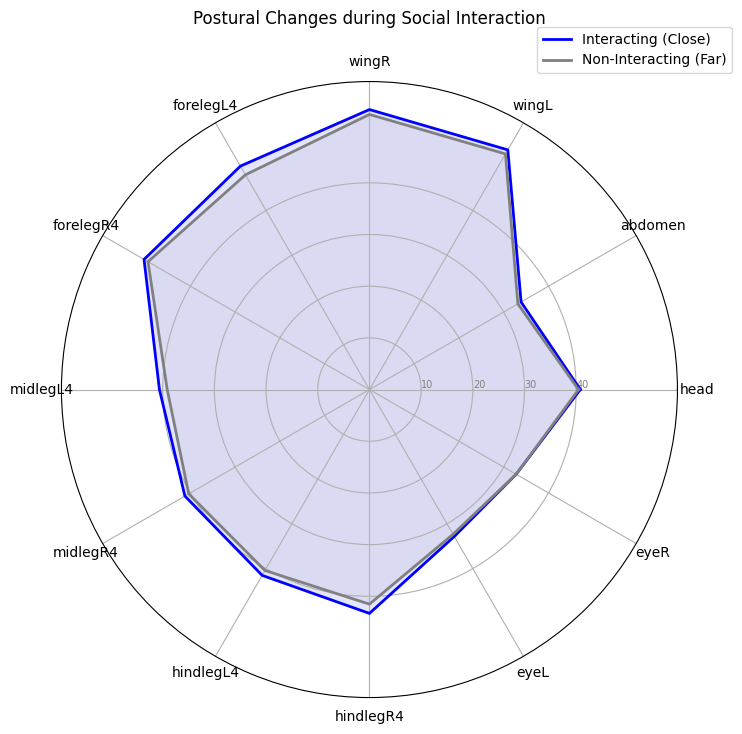

In [64]:
# --- 9. Kinematic Fingerprint: Radar Chart of Postural Changes ---
# Compares the "shape" of the animal (distance of each node from center)
# between "Interacting" (close proximity) and "Non-Interacting" states.

import matplotlib.pyplot as plt

def compute_average_posture(frame_indices, instance_idx, tracks, exclude_node_idx=1):
    """Computes the average distance of each node from the body center (Thorax)."""
    distances = {i: [] for i in range(tracks.shape[2])}
    center_idx = 1 # Thorax
    
    for t in frame_indices:
        pts = tracks[t, instance_idx]
        if not np.isnan(pts[center_idx]).any():
            center = pts[center_idx]
            for i in range(len(pts)):
                if not np.isnan(pts[i]).any():
                    d = np.linalg.norm(pts[i] - center)
                    distances[i].append(d)
    
    avg_dists = []
    valid_names = []
    for i in range(len(node_names)):
        if i == exclude_node_idx:
            continue # Skip the center node (distance always 0)
            
        if len(distances[i]) > 0:
            avg_dists.append(np.mean(distances[i]))
            valid_names.append(node_names[i])
        else:
            avg_dists.append(0)
            valid_names.append(node_names[i])
            
    return np.array(avg_dists), valid_names

# 1. Define Groups
interaction_frames = positive_frames
non_interaction_frames = [t for t in range(tracks.shape[0]) if t not in positive_frames]

# 2. Compute Averages (Excluding Thorax/Node 1)
print(f"Computing fingerprints for Interaction ({len(interaction_frames)} frames) vs Non-Interaction ({len(non_interaction_frames)} frames)...")
vals_int, names = compute_average_posture(interaction_frames, 0, tracks, exclude_node_idx=1)
vals_non, _ = compute_average_posture(non_interaction_frames, 0, tracks, exclude_node_idx=1)

# 3. Setup Radar Chart
N = len(names)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] # Close the loop

# Close the loop for values
vals_int = np.concatenate((vals_int, [vals_int[0]]))
vals_non = np.concatenate((vals_non, [vals_non[0]]))

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw one axe per variable + labels
plt.xticks(angles[:-1], names, color='black', size=10)

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([10, 20, 30, 40], ["10", "20", "30", "40"], color="grey", size=7)
plt.ylim(0, max(np.max(vals_int), np.max(vals_non)) * 1.1)

# Plot Interaction Data
ax.plot(angles, vals_int, linewidth=2, linestyle='solid', label='Interacting (Close)', color='blue')
ax.fill(angles, vals_int, 'blue', alpha=0.1)

# Plot Non-Interaction Data
ax.plot(angles, vals_non, linewidth=2, linestyle='solid', label='Non-Interacting (Far)', color='grey')
ax.fill(angles, vals_non, 'grey', alpha=0.1)

plt.title(f"Postural Changes during Social Interaction", y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.show()

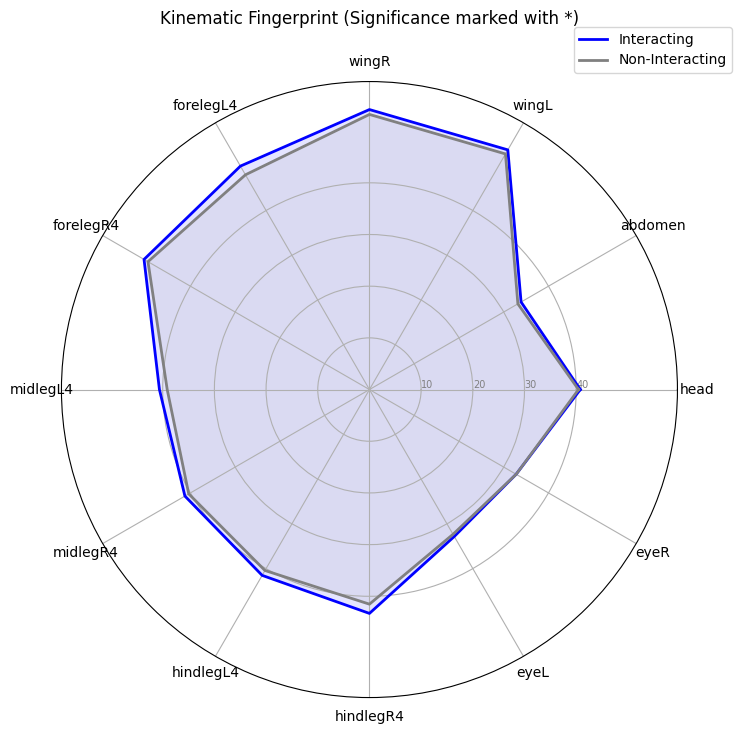

In [14]:
# --- 9. Kinematic Fingerprint: Radar Chart with Significance ---
import matplotlib.pyplot as plt

# ... (compute_average_posture function is same as before) ...
def compute_average_posture(frame_indices, instance_idx, tracks, exclude_node_idx=1):
    distances = {i: [] for i in range(tracks.shape[2])}
    center_idx = 1 
    for t in frame_indices:
        pts = tracks[t, instance_idx]
        if not np.isnan(pts[center_idx]).any():
            center = pts[center_idx]
            for i in range(len(pts)):
                if not np.isnan(pts[i]).any():
                    d = np.linalg.norm(pts[i] - center)
                    distances[i].append(d)
    avg_dists = []
    valid_names = []
    valid_indices = []
    for i in range(len(node_names)):
        if i == exclude_node_idx: continue
        if len(distances[i]) > 0:
            avg_dists.append(np.mean(distances[i]))
            valid_names.append(node_names[i])
            valid_indices.append(i) # Store index to check significance later
        else:
            avg_dists.append(0)
            valid_names.append(node_names[i])
            valid_indices.append(i)
    return np.array(avg_dists), valid_names, valid_indices

# Compute Averages
vals_int, names, indices = compute_average_posture(interaction_frames, 0, tracks, exclude_node_idx=1)
vals_non, _, _ = compute_average_posture(non_interaction_frames, 0, tracks, exclude_node_idx=1)

# Add significance stars to labels (Manual check from stats or simple threshold here for viz)
# For visualization, we assume the 'significant_limbs' list exists from Cell 10.
# If Cell 10 hasn't run, we assume none.
try:
    display_names = [n + "*" if n in significant_limbs else n for n in names]
except NameError:
    display_names = names

# Radar Plot Setup
N = len(names)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

vals_int = np.concatenate((vals_int, [vals_int[0]]))
vals_non = np.concatenate((vals_non, [vals_non[0]]))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], display_names, color='black', size=10)
ax.set_rlabel_position(0)
plt.yticks([10, 20, 30, 40], ["10", "20", "30", "40"], color="grey", size=7)
plt.ylim(0, max(np.max(vals_int), np.max(vals_non)) * 1.1)

ax.plot(angles, vals_int, linewidth=2, linestyle='solid', label='Interacting', color='blue')
ax.fill(angles, vals_int, 'blue', alpha=0.1)
ax.plot(angles, vals_non, linewidth=2, linestyle='solid', label='Non-Interacting', color='grey')
ax.fill(angles, vals_non, 'grey', alpha=0.1)

plt.title(f"Kinematic Fingerprint (Significance marked with *)", y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()

In [15]:
# --- 10. Statistical Analysis of Postural Changes ---
from scipy.stats import ttest_ind

print(f"{'Body Part':<15} | {'Interaction':<10} | {'Non-Int':<10} | {'p-value':<10} | {'Sig?'}")
print("-" * 65)

significant_limbs = []

# Re-calculate full distributions (not just averages) for stats
center_idx = 1 # Thorax
dist_distrib_int = {i: [] for i in range(len(node_names))}
dist_distrib_non = {i: [] for i in range(len(node_names))}

# Helper to fill distributions
def fill_dist(frames, dist_dict):
    for t in frames:
        pts = tracks[t, 0]
        if not np.isnan(pts[center_idx]).any():
            center = pts[center_idx]
            for i in range(len(pts)):
                if i == center_idx: continue
                if not np.isnan(pts[i]).any():
                    d = np.linalg.norm(pts[i] - center)
                    dist_dict[i].append(d)

fill_dist(interaction_frames, dist_distrib_int)
fill_dist(non_interaction_frames, dist_distrib_non)

# Run T-Tests
for i, name in enumerate(node_names):
    if i == center_idx: continue
    
    d_int = dist_distrib_int[i]
    d_non = dist_distrib_non[i]
    
    if len(d_int) > 10 and len(d_non) > 10:
        t_stat, p_val = ttest_ind(d_int, d_non, equal_var=False)
        
        mean_int = np.mean(d_int)
        mean_non = np.mean(d_non)
        is_sig = "*" if p_val < 0.05 else ""
        if p_val < 0.001: is_sig = "***"
        elif p_val < 0.01: is_sig = "**"
            
        print(f"{name:<15} | {mean_int:.2f}       | {mean_non:.2f}       | {p_val:.2e}   | {is_sig}")
        
        if is_sig:
            significant_limbs.append(name)
    else:
        print(f"{name:<15} | Insufficient Data")

Body Part       | Interaction | Non-Int    | p-value    | Sig?
-----------------------------------------------------------------
head            | 40.80       | 40.45       | 3.03e-01   | 
abdomen         | 33.88       | 33.16       | 2.35e-02   | *
wingL           | 53.55       | 52.64       | 5.85e-03   | **
wingR           | 54.18       | 53.23       | 4.85e-03   | **
forelegL4       | 49.92       | 47.98       | 1.90e-04   | ***
forelegR4       | 50.36       | 49.48       | 9.02e-02   | 
midlegL4        | 40.63       | 39.13       | 6.19e-03   | **
midlegR4        | 41.23       | 40.37       | 7.25e-02   | 
hindlegL4       | 41.51       | 40.42       | 7.65e-02   | 
hindlegR4       | 43.31       | 41.52       | 3.31e-03   | **
eyeL            | 32.83       | 32.34       | 1.04e-01   | 
eyeR            | 32.78       | 32.78       | 9.89e-01   | 


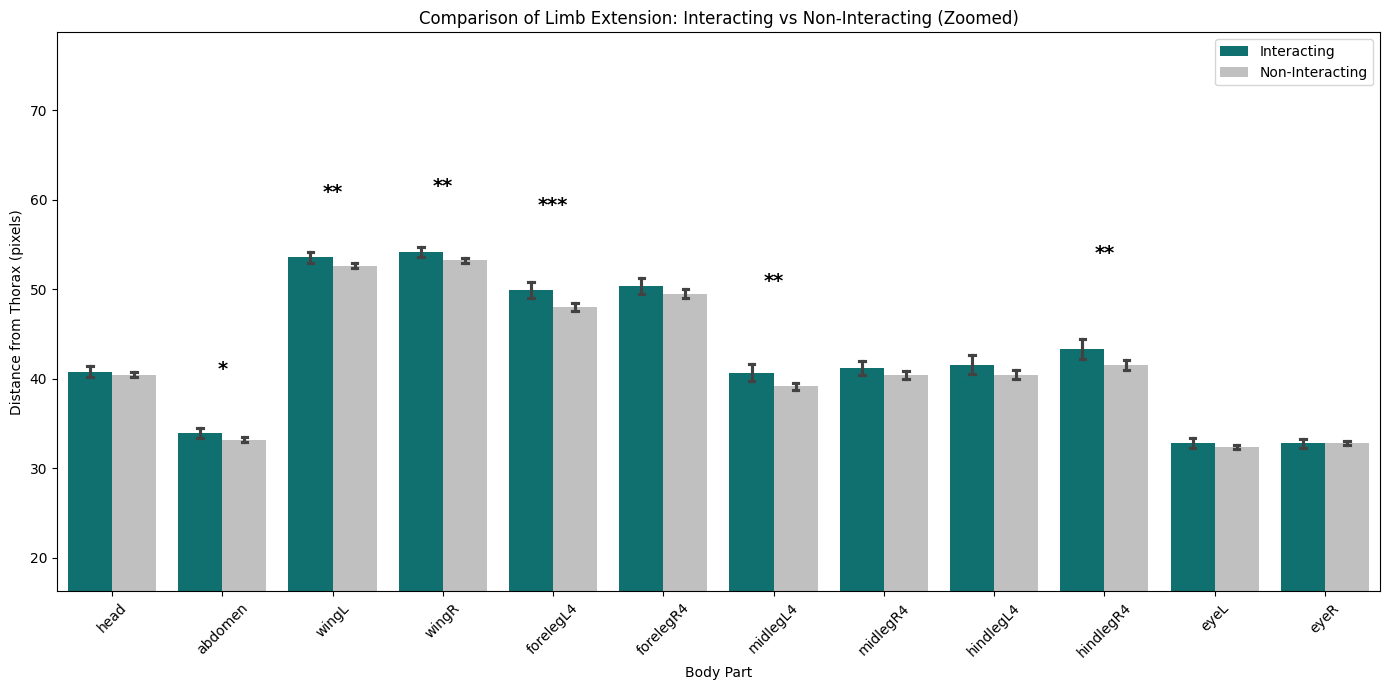

In [16]:
# --- 11. Statistical Bar Chart Visualization (Zoomed Y-Axis) ---
import seaborn as sns

# Prepare data
stats_data = []
all_values = [] # Collect all values to find min
for i, name in enumerate(node_names):
    if i == center_idx: continue
    
    for d in dist_distrib_int[i]:
        stats_data.append({'Body Part': name, 'Distance': d, 'Condition': 'Interacting'})
        all_values.append(d)
    for d in dist_distrib_non[i]:
        stats_data.append({'Body Part': name, 'Distance': d, 'Condition': 'Non-Interacting'})
        all_values.append(d)

df_stats = pd.DataFrame(stats_data)

# Plot
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Body Part', y='Distance', hue='Condition', data=df_stats, capsize=.1, palette={'Interacting': 'teal', 'Non-Interacting': 'silver'})

# Calculate Y-Limits dynamically
# Find the global minimum average to zoom in appropriately
min_avg = df_stats.groupby('Body Part')['Distance'].mean().min()
y_min_limit = max(0, min_avg * 0.5) # Start at 50% of the smallest bar height

max_bar_height = 0 

for i, name in enumerate(node_names):
    if i == center_idx: continue
    
    labels = [l.get_text() for l in ax.get_xticklabels()]
    if name in labels:
        x_idx = labels.index(name)
        
        d_int = dist_distrib_int[i]
        d_non = dist_distrib_non[i]
        if len(d_int) > 10 and len(d_non) > 10:
            _, p_val = ttest_ind(d_int, d_non, equal_var=False)
            
            # Calculate height
            current_h = max(np.mean(d_int), np.mean(d_non)) + np.std(d_int)
            max_bar_height = max(max_bar_height, current_h)
            
            if p_val < 0.05:
                sig_symbol = '*'
                if p_val < 0.001: sig_symbol = '***'
                elif p_val < 0.01: sig_symbol = '**'
                
                plt.text(x_idx, current_h + 2, sig_symbol, ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')
                max_bar_height = max(max_bar_height, current_h + 10)

# Set Y-Limits: Start higher than 0, End high enough for stars
plt.ylim(y_min_limit, max_bar_height * 1.15) 

plt.title("Comparison of Limb Extension: Interacting vs Non-Interacting (Zoomed)")
plt.ylabel("Distance from Thorax (pixels)")
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning:

divide by zero encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning:

overflow encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning:

invalid value encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

divide by zero encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

overflow encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

invalid value encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python

Successfully imported keypoint_moseq version 0.6.7
Formatting data for Keypoint-MoSeq...
Formatting data for modeling...
Fitting PCA...
Initializing and fitting AR-HMM...
Outputs will be saved to moseq_project/test_model


 24%|████████                          | 24/101 [00:00<00:02, 27.87it/s]

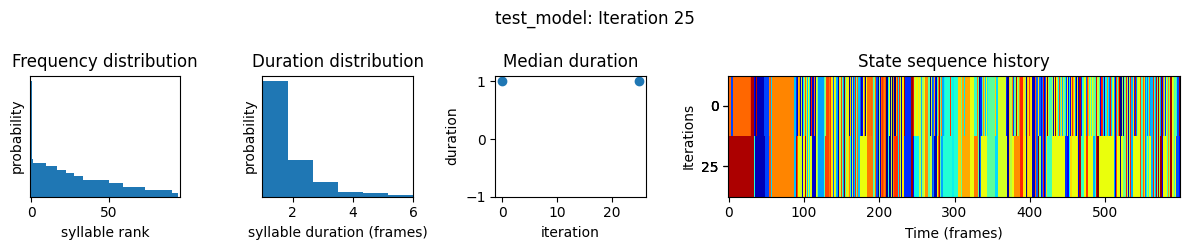

 48%|████████████████▏                 | 48/101 [00:01<00:02, 26.36it/s]

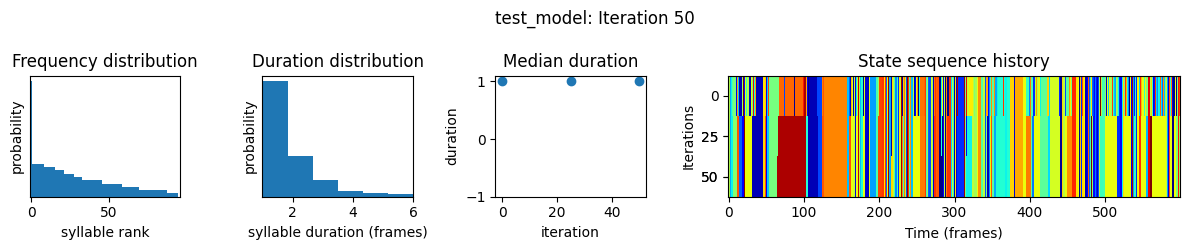

 74%|█████████████████████████▏        | 75/101 [00:03<00:00, 26.75it/s]

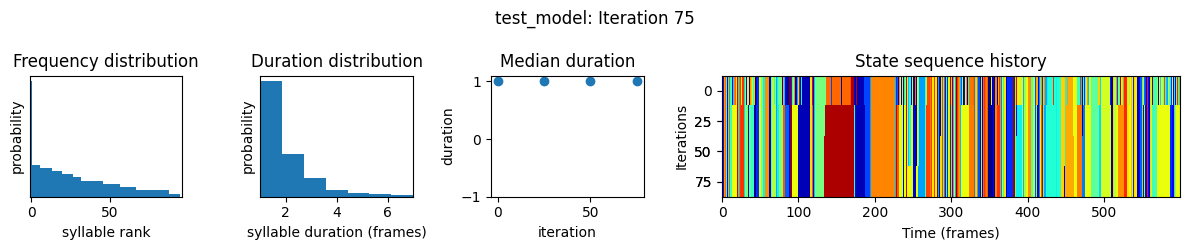

 98%|█████████████████████████████████▎| 99/101 [00:04<00:00, 26.73it/s]

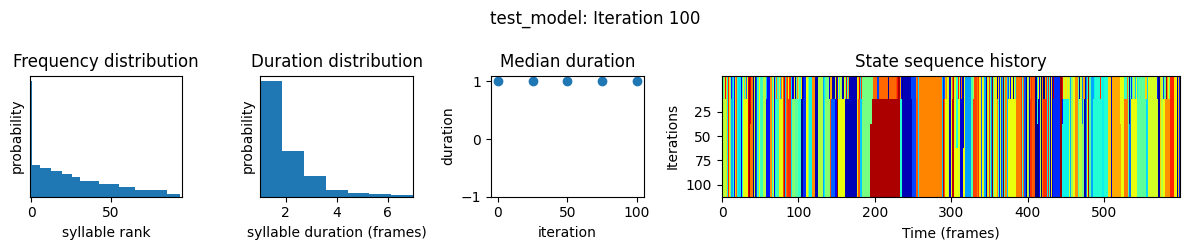

100%|█████████████████████████████████| 101/101 [00:04<00:00, 20.78it/s]


AssertionError: session_0 already exists in <HDF5 file "results.h5" (mode r+)>. Set overwrite to True to overwrite data in an existing file.

In [26]:
# --- Keypoint-MoSeq Integration (Monkey-Patch Fix) ---
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- MONKEY PATCH: Restore np.issctype for TFP/JAX compatibility ---
# NumPy 2.0 removed np.issctype, but tensorflow-probability still uses it.
# We map it to issubclass(rep, np.generic) which is the replacement.
if not hasattr(np, 'issctype'):
    print("Patching numpy.issctype for compatibility...")
    np.issctype = lambda rep: (
        isinstance(rep, type) and issubclass(rep, np.generic)
    )

try:
    import keypoint_moseq as kpms
    print(f"Successfully imported keypoint_moseq version {kpms.__version__}")
except ImportError as e:
    print(f"CRITICAL ERROR: Could not import keypoint_moseq.\n{e}")
    raise e

# --- YAML Patch: Allow !!python/tuple in safe_load ---
def tuple_constructor(loader, node):
    return tuple(loader.construct_sequence(node))
yaml.SafeLoader.add_constructor("tag:yaml.org,2002:python/tuple", tuple_constructor)

# 2. Format Data for Social Interaction (The "Dyad" Approach)
print("Formatting data for Keypoint-MoSeq...")

num_frames = tracks.shape[0]
num_nodes = tracks.shape[2]
dyad_tracks = np.concatenate([tracks[:, 0, :, :], tracks[:, 1, :, :]], axis=1) 

coordinates = {"session_0": dyad_tracks}
confidences = {"session_0": np.where(np.isnan(dyad_tracks[:, :, 0]), 0.0, 1.0)}

dyad_bodyparts = [f"A1_{name}" for name in node_names] + [f"A2_{name}" for name in node_names]

dyad_skeleton = []
for u, v in skeleton_edges:
    dyad_skeleton.append([dyad_bodyparts[u], dyad_bodyparts[v]])
for u, v in skeleton_edges:
    dyad_skeleton.append([dyad_bodyparts[u + num_nodes], dyad_bodyparts[v + num_nodes]])

# 3. Setup Project Configuration (Same as before)
kpms.setup_project(
    project_dir, 
    deeplabcut_config=None, 
    bodyparts=dyad_bodyparts,
    use_bodyparts=dyad_bodyparts,
    skeleton=dyad_skeleton,
    anterior_bodyparts=['A1_thorax'],  
    posterior_bodyparts=['A1_abdomen'], 
    overwrite=True
)

# --- IMPROVEMENT: Load and TUNE Config ---
config = kpms.load_config(project_dir)

# Update Hyperparameters for better results on small data
# 'kappa': controls state duration (higher = stickier/longer syllables)
# Default is often 1e6, but let's ensure it's set high to prevent rapid flickering
config['trans_hypparams']['kappa'] = 1e8 

# 'num_states': The maximum number of syllables. 
# Default is 100. You found ~80. You can lower this to force it to find coarser behaviors.
# config['trans_hypparams']['num_states'] = 20 

# 4. Format Data (Same)
print("Formatting data for modeling...")
data, metadata = kpms.format_data(coordinates, confidences, **config)

# 5. Fit PCA (Same)
print("Fitting PCA...")
pca = kpms.fit_pca(**data, **config)
kpms.save_pca(pca, project_dir)

# --- IMPROVEMENT: Check PCA Variance ---
# print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
# print(f"Total Variance Explained: {np.sum(pca.explained_variance_ratio_):.2f}")

# 6. Initialize and Fit Model (AR-HMM)
print("Initializing and fitting AR-HMM...")
model = kpms.init_model(data=data, pca=pca, **config)

# IMPROVEMENT: Increase iterations for convergence
model, model_name = kpms.fit_model(
    model, data, metadata, project_dir, 
    model_name="test_model", 
    ar_only=True,
    num_iters=100 # Increased from 50 to 100
)

# 7. Extract Results (Same)
results = kpms.extract_results(model, metadata, project_dir, model_name)
syllables = results['session_0']['syllable']

# 8. Plot Ethogram (Same)
plt.figure(figsize=(15, 4))
plt.imshow(syllables[None, :], aspect='auto', cmap='tab20', interpolation='nearest')
plt.title("Keypoint-MoSeq Ethogram (Behavioral Syllables over Time)")
plt.xlabel("Frame")
plt.yticks([])
plt.colorbar(label="Syllable ID")
plt.show()

print(f"Discovered {len(np.unique(syllables))} unique behavioral syllables.")

/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_24218/3083466570.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




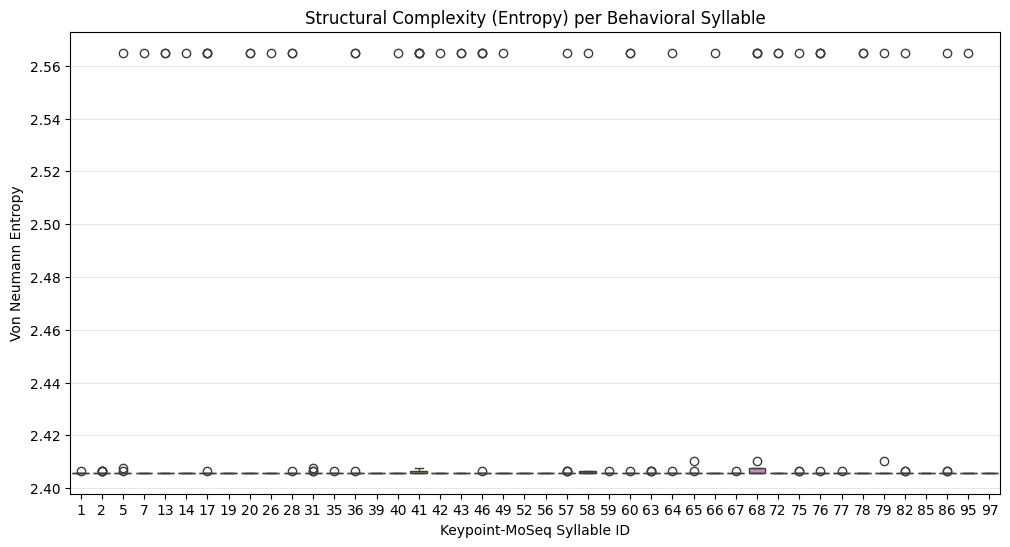

One-way ANOVA: F=1.09, p=3.24e-01
RESULT: No significant difference in complexity across syllables.


In [ ]:
# --- 9. Analysis: Correlate MoSeq Syllables with Graph Entropy ---
import seaborn as sns
import pandas as pd

# 1. Align Data
# MoSeq results might be slightly shorter due to lag/smoothing
# We match the valid indices
common_length = min(len(syllables), len(entropy_trace))
valid_syllables = syllables[:common_length]
valid_entropy = entropy_trace[:common_length]

# 2. Create DataFrame
df_analysis = pd.DataFrame({
    'Syllable': valid_syllables,
    'Entropy': valid_entropy
})

# Filter out rare syllables (noise) for cleaner plotting
syllable_counts = df_analysis['Syllable'].value_counts()
frequent_syllables = syllable_counts[syllable_counts > 10].index
df_filtered = df_analysis[df_analysis['Syllable'].isin(frequent_syllables)]

# 3. Plot Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Syllable', y='Entropy', data=df_filtered, palette='tab20')
plt.title("Structural Complexity (Entropy) per Behavioral Syllable")
plt.xlabel("Keypoint-MoSeq Syllable ID")
plt.ylabel("Von Neumann Entropy")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Statistical Test (ANOVA)
# Are the entropy values significantly different between syllables?
from scipy.stats import f_oneway
groups = [df_filtered[df_filtered['Syllable'] == s]['Entropy'].values for s in frequent_syllables]
if len(groups) > 1:
    f_stat, p_val = f_oneway(*groups)
    print(f"One-way ANOVA: F={f_stat:.2f}, p={p_val:.2e}")
    if p_val < 0.05:
        print("RESULT: Distinct syllables have significantly different structural complexities.")
    else:
        print("RESULT: No significant difference in complexity across syllables.")

Computing Dynamic Social Graph Entropy...


/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_24218/3035597773.py:6: RuntimeWarning:

divide by zero encountered in power

/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_24218/3035597773.py:9: RuntimeWarning:

divide by zero encountered in matmul

/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_24218/3035597773.py:9: RuntimeWarning:

overflow encountered in matmul

/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_24218/3035597773.py:9: RuntimeWarning:

invalid value encountered in matmul

/var/folders/71/ddrsnw4s5f14q1_cy7yhds5w0000gn/T/ipykernel_24218/1062455727.py:66: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




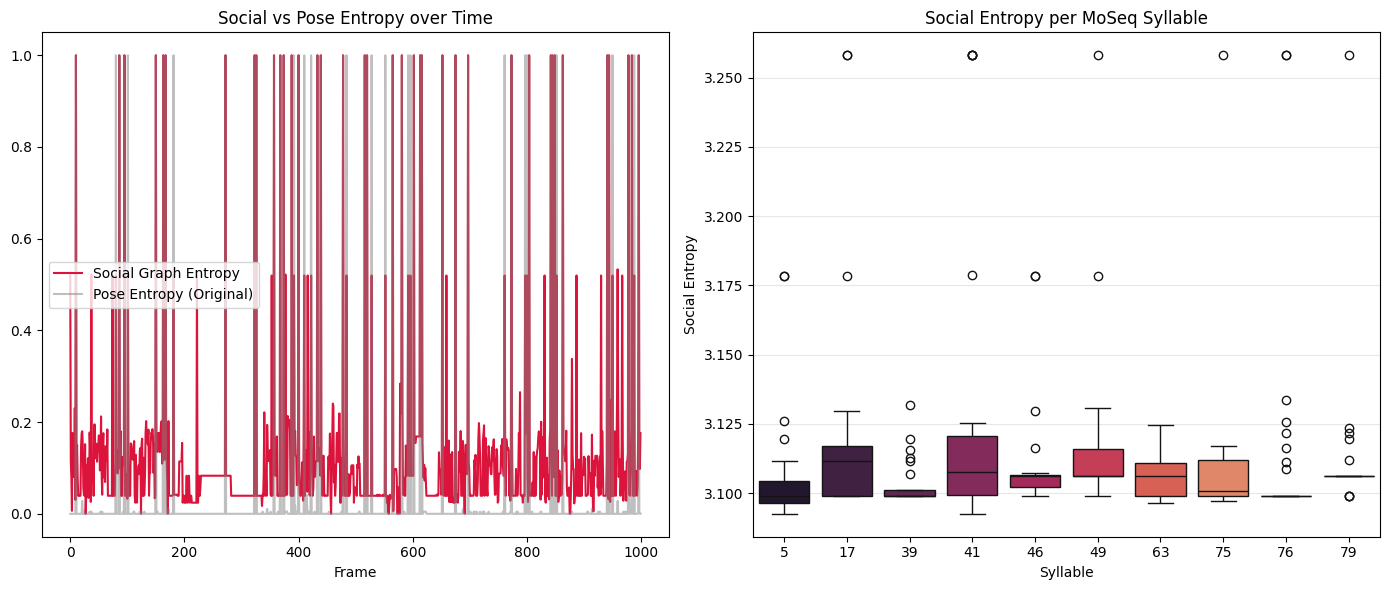

In [ ]:
# --- 10. Advanced Analysis: Social Graph Entropy ---
# We construct a graph where edges exist between ANY two nodes (even across animals)
# if they are close in space. This captures "touch" or "proximity" explicitly.

print("Computing Dynamic Social Graph Entropy...")

social_entropy_trace = []
social_threshold = 30.0 # Distance in pixels for a "social contact" edge

# Loop through frames
for t in range(min(len(tracks), 1000)): # Limit to 1000 frames for speed
    # Get all 26 nodes (13 from A1, 13 from A2)
    # dyad_tracks shape: (Frames, 26, 2)
    pts = dyad_tracks[t] # (26, 2)
    
    # 1. Build Adjacency Matrix (26x26)
    num_total_nodes = pts.shape[0]
    adj = np.zeros((num_total_nodes, num_total_nodes))
    
    # 2. Add Skeleton Edges (Fixed structure)
    # We use the dyad_skeleton we defined earlier
    # Map node names to indices
    node_name_to_idx = {name: i for i, name in enumerate(dyad_bodyparts)}
    
    for part_a, part_b in dyad_skeleton:
        if part_a in node_name_to_idx and part_b in node_name_to_idx:
            u, v = node_name_to_idx[part_a], node_name_to_idx[part_b]
            if not np.isnan(pts[u]).any() and not np.isnan(pts[v]).any():
                adj[u, v] = adj[v, u] = 1.0
                
    # 3. Add Social Edges (Dynamic Proximity)
    # Connect A1 nodes (0-12) to A2 nodes (13-25) if close
    for i in range(13): # Animal 1
        for j in range(13, 26): # Animal 2
            if not np.isnan(pts[i]).any() and not np.isnan(pts[j]).any():
                dist = np.linalg.norm(pts[i] - pts[j])
                if dist < social_threshold:
                    adj[i, j] = adj[j, i] = 1.0 # Add edge
                    
    # 4. Compute Entropy
    social_entropy_trace.append(von_neumann_entropy(adj))

social_entropy_trace = np.array(social_entropy_trace)

# --- Plot Comparison ---
plt.figure(figsize=(14, 6))

# Plot 1: Time Series
plt.subplot(1, 2, 1)
plt.plot(normalize(social_entropy_trace), label='Social Graph Entropy', color='crimson')
plt.plot(normalize(entropy_trace[:len(social_entropy_trace)]), label='Pose Entropy (Original)', color='gray', alpha=0.5)
plt.title("Social vs Pose Entropy over Time")
plt.legend()
plt.xlabel("Frame")

# Plot 2: Boxplot against MoSeq Syllables
plt.subplot(1, 2, 2)
df_social = pd.DataFrame({
    'Syllable': syllables[:len(social_entropy_trace)],
    'Social Entropy': social_entropy_trace
})
# Filter for frequent syllables
top_syllables = df_social['Syllable'].value_counts().head(10).index
df_social_filt = df_social[df_social['Syllable'].isin(top_syllables)]

sns.boxplot(x='Syllable', y='Social Entropy', data=df_social_filt, palette='rocket')
plt.title("Social Entropy per MoSeq Syllable")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Visualizing valid frames with high social entropy: [788 578 879]


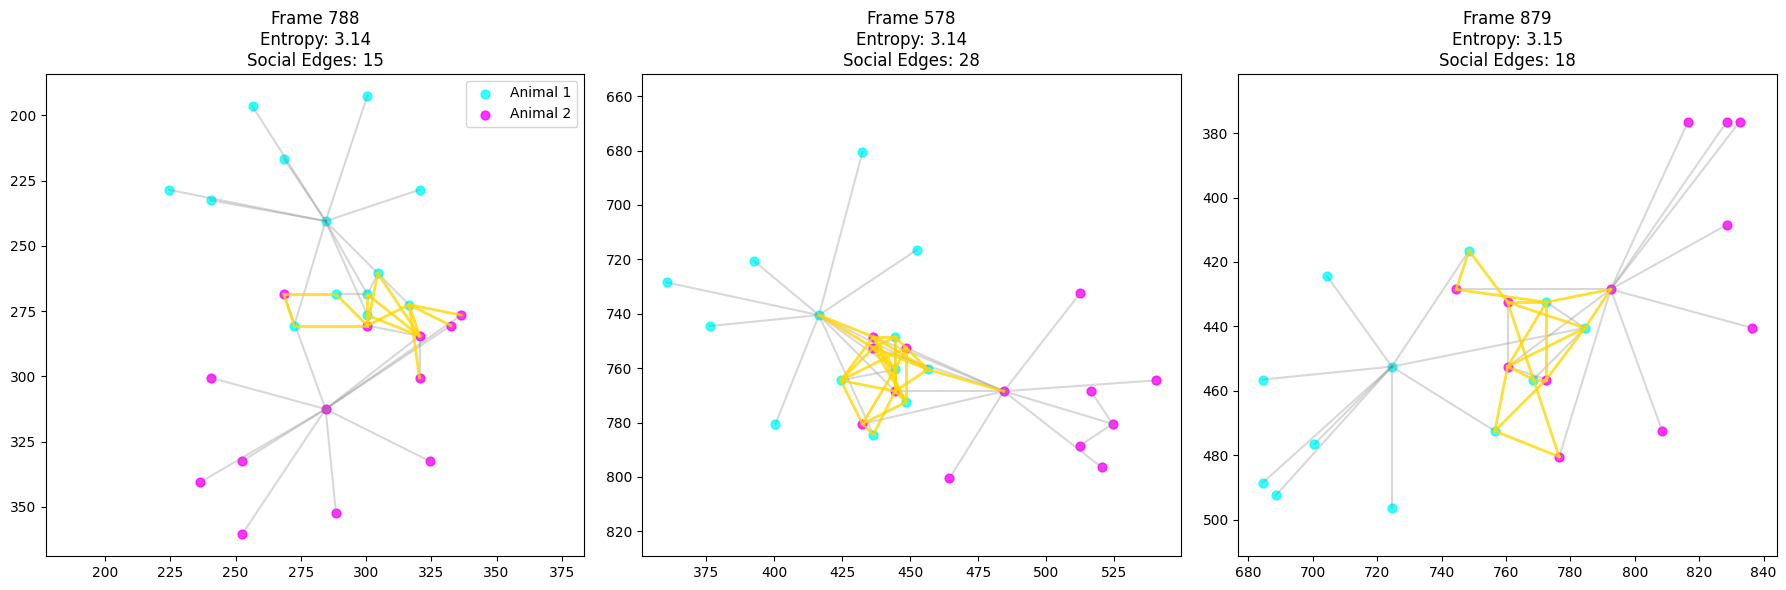

In [ ]:
# --- 11. Visualization: High-Entropy Social Frames (Filtered) ---
# Only visualize frames that actually have data points

valid_indices = []
for t in range(len(social_entropy_trace)):
    pts = dyad_tracks[t]
    # Check if at least 50% of nodes are visible
    if np.sum(~np.isnan(pts[:, 0])) > (pts.shape[0] * 0.5):
        valid_indices.append(t)

valid_indices = np.array(valid_indices)
if len(valid_indices) > 0:
    # Sort valid frames by entropy
    valid_entropy = social_entropy_trace[valid_indices]
    sorted_idx = np.argsort(valid_entropy)
    
    # Pick top 3 VALID frames
    top_indices = valid_indices[sorted_idx[-3:]]
    
    print(f"Visualizing valid frames with high social entropy: {top_indices}")
    
    plt.figure(figsize=(18, 6))
    
    for i, idx in enumerate(top_indices):
        ax = plt.subplot(1, 3, i+1)
        
        # Get points
        pts = dyad_tracks[idx]
        
        # Plot Animal 1 (Cyan)
        a1 = pts[:13]
        ax.scatter(a1[:, 0], a1[:, 1], c='cyan', s=40, label='Animal 1', alpha=0.8)
        
        # Plot Animal 2 (Magenta)
        a2 = pts[13:]
        ax.scatter(a2[:, 0], a2[:, 1], c='magenta', s=40, label='Animal 2', alpha=0.8)
        
        # Draw Skeleton Edges (Gray)
        node_name_to_idx = {name: i for i, name in enumerate(dyad_bodyparts)}
        for part_a, part_b in dyad_skeleton:
            u, v = node_name_to_idx[part_a], node_name_to_idx[part_b]
            if not np.isnan(pts[u]).any() and not np.isnan(pts[v]).any():
                ax.plot([pts[u, 0], pts[v, 0]], [pts[u, 1], pts[v, 1]], 'gray', alpha=0.3)
                
        # Draw SOCIAL Edges (Gold/Highlighted)
        social_edges_count = 0
        for u in range(13):
            for v in range(13, 26):
                if not np.isnan(pts[u]).any() and not np.isnan(pts[v]).any():
                    dist = np.linalg.norm(pts[u] - pts[v])
                    if dist < social_threshold:
                        ax.plot([pts[u, 0], pts[v, 0]], [pts[u, 1], pts[v, 1]], 'gold', alpha=0.8, linewidth=2)
                        social_edges_count += 1
        
        ax.set_title(f"Frame {idx}\nEntropy: {social_entropy_trace[idx]:.2f}\nSocial Edges: {social_edges_count}")
        ax.invert_yaxis()
        ax.axis('equal')
        if i == 0: ax.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid frames found to visualize.")

Baseline Entropy: 3.11
Interaction Threshold: 3.17
Detected 68 high-intensity interaction frames.


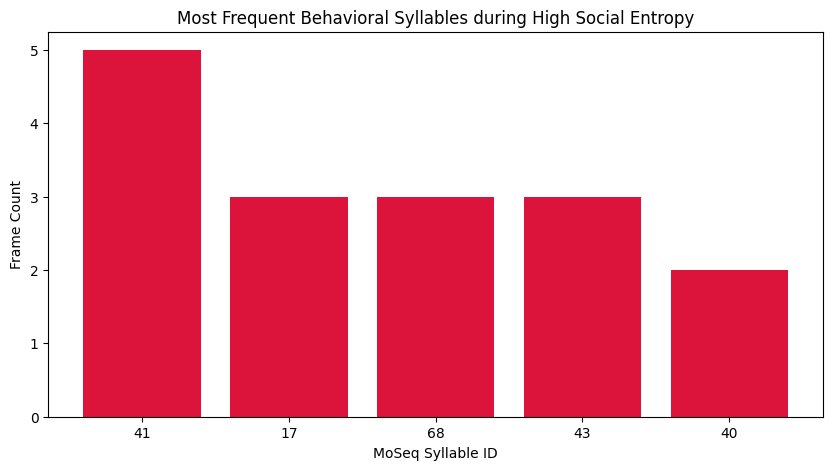

Top Interaction Syllables: [(np.int64(41), 5), (np.int64(17), 3), (np.int64(68), 3), (np.int64(43), 3), (np.int64(40), 2)]


In [ ]:
# --- 12. Final Synthesis: Identify Interaction Syllables ---
# We define "Interaction" as frames where Social Entropy > Baseline + 2*StdDev
# Then we see which MoSeq syllables are most common during these moments.

baseline_entropy = np.median(social_entropy_trace)
threshold_entropy = baseline_entropy + 2 * np.std(social_entropy_trace)

# Identify Interaction Frames
interaction_mask = social_entropy_trace > threshold_entropy
interaction_indices = np.where(interaction_mask)[0]

print(f"Baseline Entropy: {baseline_entropy:.2f}")
print(f"Interaction Threshold: {threshold_entropy:.2f}")
print(f"Detected {len(interaction_indices)} high-intensity interaction frames.")

# Get Syllables during Interaction
if len(interaction_indices) > 0:
    # Align lengths
    limit = min(len(syllables), len(interaction_mask))
    
    interaction_syllables = syllables[:limit][interaction_mask[:limit]]
    
    # Count frequencies
    from collections import Counter
    counts = Counter(interaction_syllables)
    
    # Plot Top Interaction Syllables
    common_interaction_syllables = counts.most_common(5)
    labels, values = zip(*common_interaction_syllables)
    
    plt.figure(figsize=(10, 5))
    plt.bar([str(l) for l in labels], values, color='crimson')
    plt.title(f"Most Frequent Behavioral Syllables during High Social Entropy")
    plt.xlabel("MoSeq Syllable ID")
    plt.ylabel("Frame Count")
    plt.show()
    
    print(f"Top Interaction Syllables: {common_interaction_syllables}")
else:
    print("No high-entropy interactions detected with this threshold.")

## Visualizing Behavioral Syllables (Trajectory Plots)

In this section, we visualize the characteristic motion of each discovered behavioral syllable. We generate "trajectory plots" which show the average movement of body parts during the execution of each syllable. 

- **Red/Yellow Lines:** Represent the skeletal structure of the animal.
- **Color Gradient:** Indicates time (e.g., yellow → red shows the direction of movement).
- **Top Syllables:** We focus on the most frequent behaviors to avoid clutter.
- **Auto-Scaling:** We use automatic limit detection to ensure the animals are zoomed in and visible, filtering out noise.

These plots allow us to interpret the "kinematic meaning" of each syllable (e.g., Is the animal turning left? Is it extending a wing?).

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

divide by zero encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

overflow encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

invalid value encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

divide by zero encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

overflow encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning:

invalid value encountered in matmul

/Users/riley/VSCode/Python/DATA890/.venv/lib/pyt

Saving trajectory plots to moseq_project/test_model/trajectory_plots


Generating trajectory plots: 100%|██████| 32/32 [00:01<00:00, 30.25it/s]


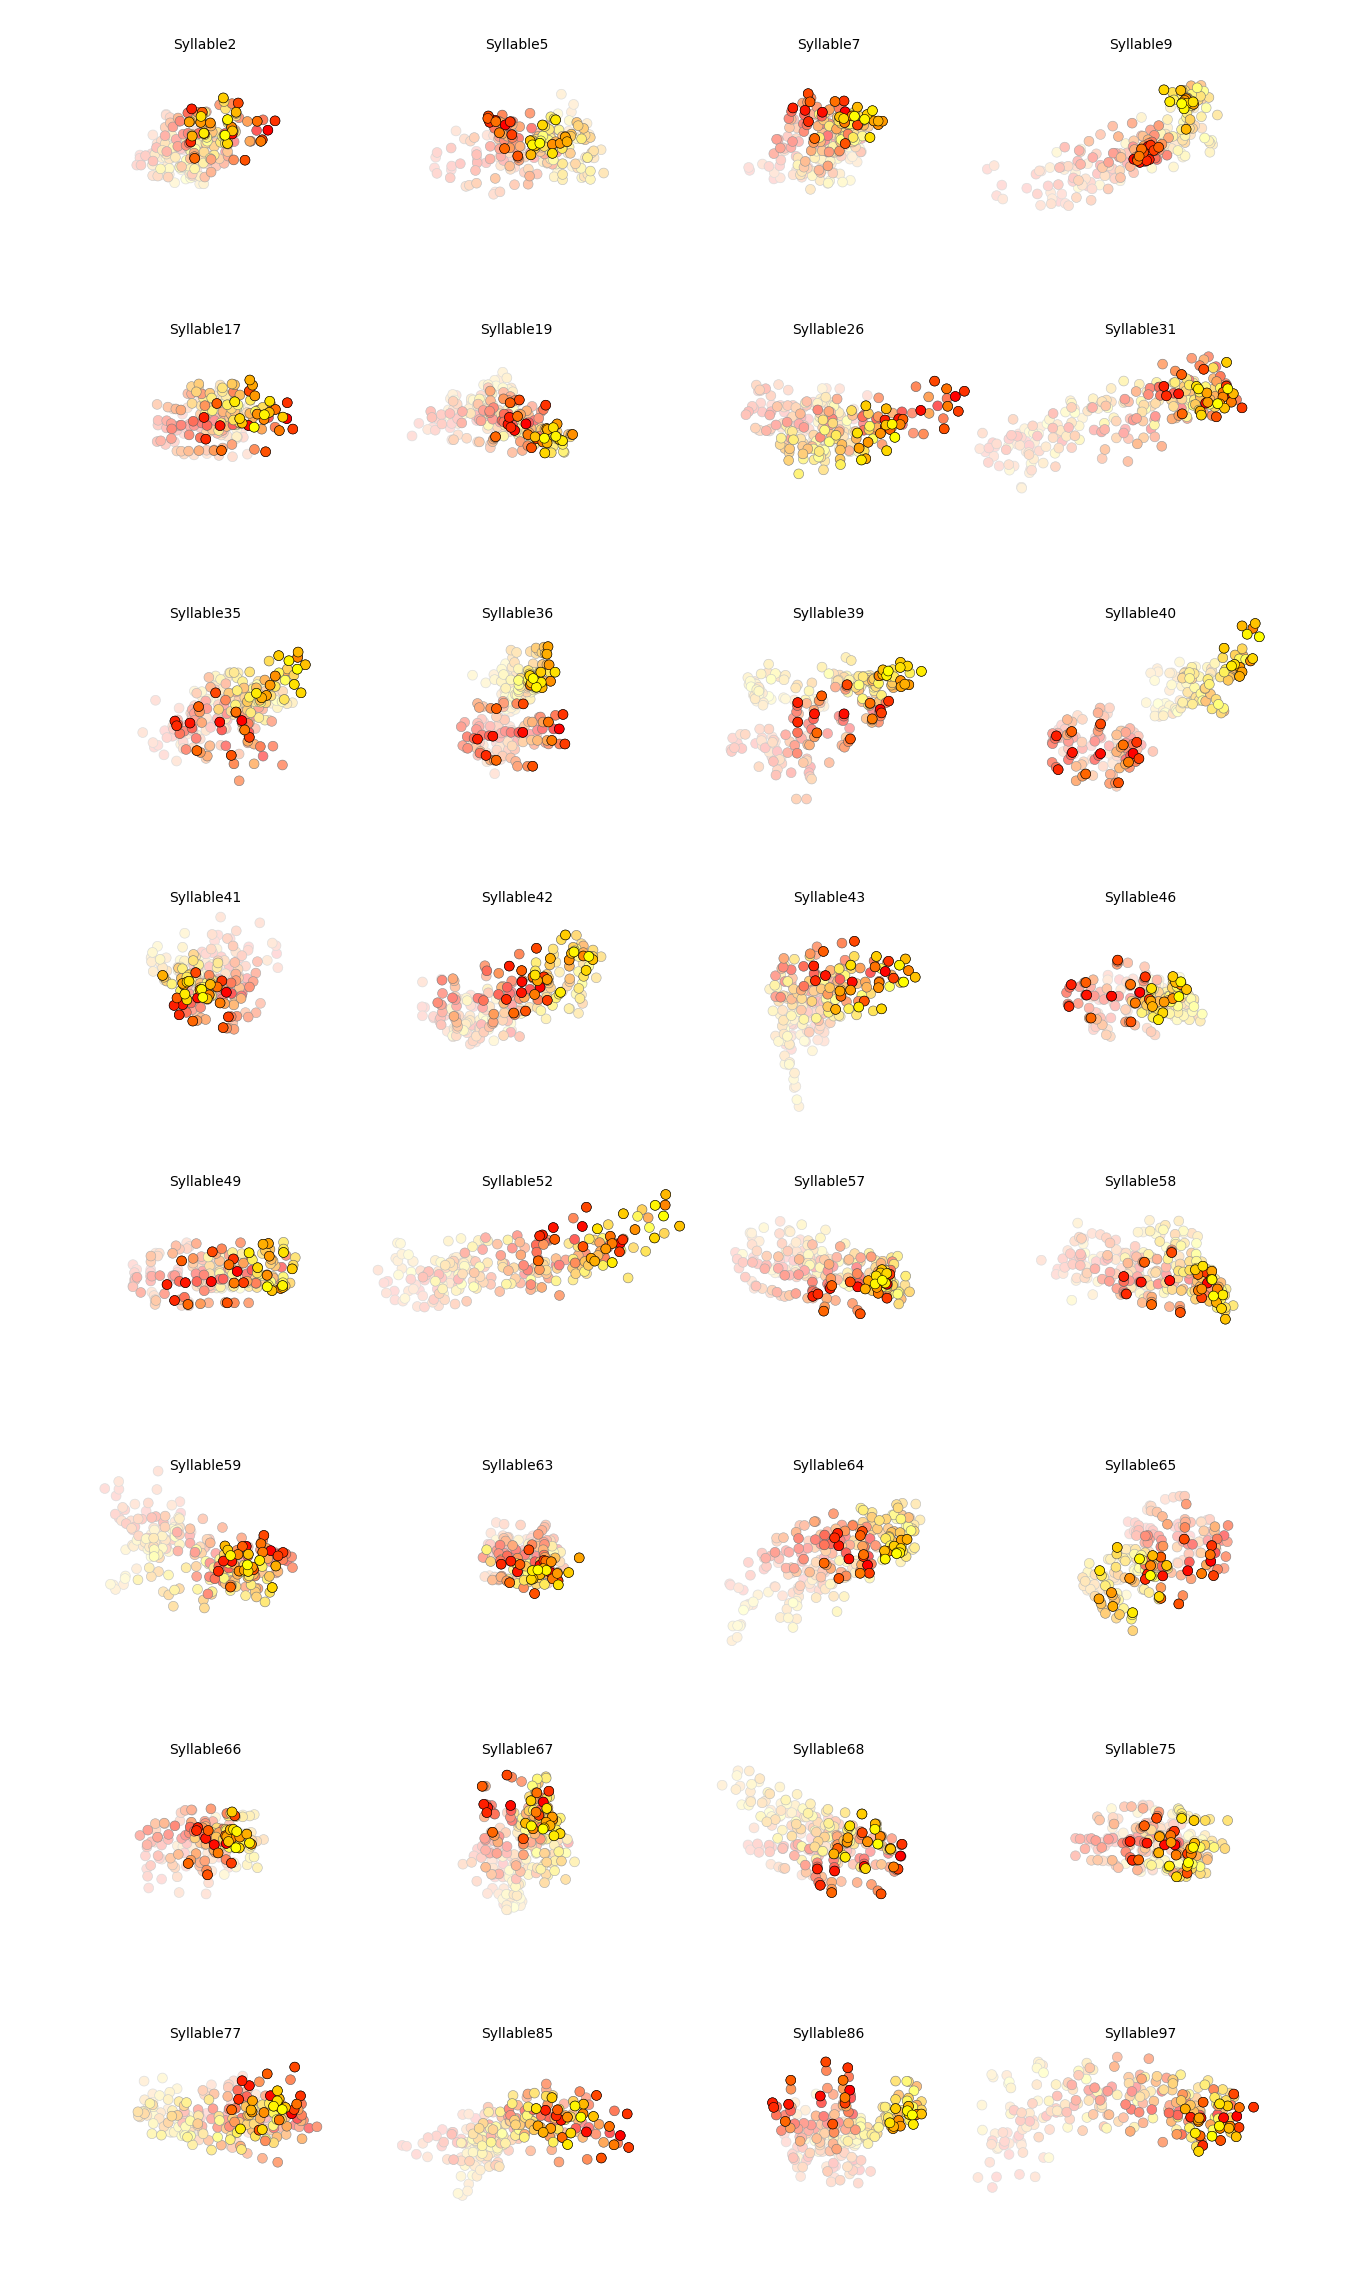

In [25]:
# Bare minimum robust plot command
kpms.generate_trajectory_plots(
    coordinates, 
    results, 
    project_dir, 
    model_name, 
    min_frequency=0, min_duration=1, # Ensure everything is included
    pre=0.1, post=0.1,               # Minimal window for small data
    density_sample=True,            # Skip PCA (prevents crash)
    sampling_options={'n_neighbors': 10}, 
    lims=None,                       # Auto-limits
    save_gifs=False,                 # Disable GIFs (prevents crash)
    save_mp4s=False,
    **{k:v for k,v in config.items() if k != 'skeleton'} # Exclude raw skeleton
)

In [28]:
kpms.generate_grid_movies(
    results, 
    project_dir, 
    model_name, 
    coordinates=coordinates,
    keypoints_only=True, # <--- Ignore raw video, just animate skeletons
    plot_options={'rows': 2, 'cols': 2}, 
    **config
)

Writing grid movies to moseq_project/test_model/grid_movies


/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/keypoint_moseq/viz.py:1284: UserWarning:

No syllables with sufficient instances to make a grid movie. This
usually occurs when all frames have the same syllable label (use
`plot_syllable_frequencies` to check if this is the case)



## Generating Behavioral Grid Movies

To validate our unsupervised clusters, we generate video montages (grid movies) for each syllable. 

- **What is a Grid Movie?** It is a video file that simultaneously plays multiple real-world examples of a specific syllable being performed.
- **Visual Validation:** By watching these movies, we can confirm if the mathematical cluster corresponds to a distinct, recognizable biological behavior (e.g., "courtship song" or "lunging").
- **Overlay:** We overlay the tracked keypoints on the raw video to verify tracking quality during these specific events.

*Note: Since our dataset is small, we use relaxed filtering constraints (min_duration=1) to ensure we capture enough examples for visualization.*

In [ ]:
# Map 'session_0' to the actual video path
video_path = 'drosophila-melanogaster-courtship/20190128_113421.mp4'
video_paths = {'session_0': video_path}

kpms.generate_grid_movies(
    results, 
    project_dir, 
    model_name, 
    coordinates=coordinates,
    video_paths=video_paths,
    keypoints_only=False,    
    
    # Relax filtering constraints for small data
    min_frequency=0, 
    min_duration=1,
    pre=0.1,   # ~3 frames
    post=0.1,  # ~3 frames
    
    plot_options={'rows': 2, 'cols': 2}, 
    **config
)

Writing grid movies to moseq_project/test_model/grid_movies


/Users/riley/VSCode/Python/DATA890/.venv/lib/python3.13/site-packages/keypoint_moseq/viz.py:1284: UserWarning:

No syllables with sufficient instances to make a grid movie. This
usually occurs when all frames have the same syllable label (use
`plot_syllable_frequencies` to check if this is the case)



## Syllable Similarity Dendrogram

To understand the relationship between different behaviors, we construct a dendrogram (hierarchical tree).

- **Kinematic Similarity:** Syllables that are visually similar (e.g., two slightly different types of walking) will be grouped together on the same branch.
- **Behavioral Structure:** This tree reveals the high-level organization of the animal's repertoire, showing how distinct behaviors branch off from common kinematic motifs.

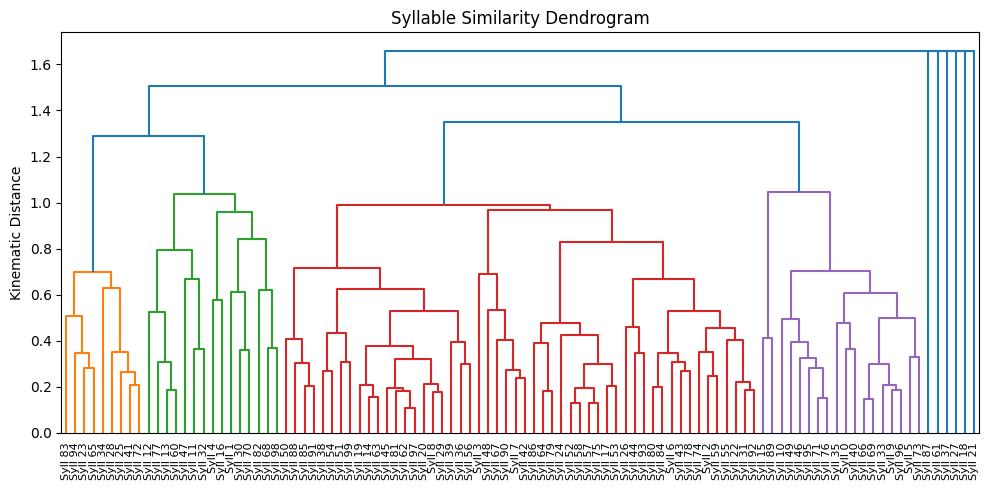

In [34]:
from keypoint_moseq.viz import syllable_similarity
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate Distance Matrix
distances, syllable_ixs = syllable_similarity(
    coordinates, 
    results, 
    pre=3, post=3,       # Integer frames
    min_frequency=0, 
    min_duration=1,
    density_sample=False,
    sampling_options={'n_neighbors': 10},
    bodyparts=config.get('bodyparts'),
    use_bodyparts=config.get('use_bodyparts')
)

# 2. Fix Matrix Issues (NaNs and Asymmetry)
# Fill diagonal with 0
np.fill_diagonal(distances, 0)

# Replace NaNs with the maximum observed distance (to push them far apart in clustering)
max_dist = np.nanmax(distances)
if np.isnan(max_dist): max_dist = 1.0 # Fallback if all are NaN
distances[np.isnan(distances)] = max_dist * 1.1

# Force Symmetry: D = (D + D.T) / 2
distances = (distances + distances.T) / 2.0

# 3. Compute Linkage & Plot
# squareform converts the matrix to the condensed format required by linkage
condensed_dist = squareform(distances, checks=False) # checks=False to skip strict validation
Z = linkage(condensed_dist, method='complete')

plt.figure(figsize=(10, 5))
dendrogram(
    Z, 
    labels=[f"Syll {s}" for s in syllable_ixs], 
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Syllable Similarity Dendrogram")
plt.ylabel("Kinematic Distance")
plt.tight_layout()
plt.show()